# Exciton contribution to the spin susceptibility — one-D and two-D terms

Following the structure of `StaticSpinSucep`, the excitonic corrections to the spin susceptibility on a static magnetic background are

$$R^R=R^R_{\rm bare}+R^R_{1D}+R^R_{2D}.$$

The **two-D term** carries two exciton propagators and two one-magnetization vertices. Its resonant kernel is

$$K^{(2D)}_{ll',ab}(\Omega)={\rm Tr}\left[D(\Omega)\,\Lambda_l^a(\Omega)\,D(\Omega)\,\Lambda_{l'}^b(\Omega)\right],
\qquad \Lambda_l^a=\frac{\partial\Pi}{\partial M_l^a}.$$

The **one-D term** carries one exciton propagator and the two-magnetization vertex,

$$R^{(1D),R}_{ll',ab}(\Omega)=C_1\,{\rm Tr}\left[D(\Omega)\,\Lambda^{ll',ab}(\Omega)\right],
\qquad \Lambda^{ll',ab}=\frac{\partial^2\Pi}{\partial M_l^a\partial M_{l'}^b}.$$

This notebook implements both terms for the **polarized two-layer model** in the single-mode (bright A exciton) framework of `BrightExcitonMode.ipynb`, using the calibrated CrSBr parameter set.

The natural magnetic variable is the moment overlap $x\equiv\mathbf M_1\cdot\mathbf M_2$, and three structural results make everything analytic:

1. **Trivial chain rule**: $\partial x/\partial M_1^a=M_2^a$ exactly, so $\Lambda_1^a(\Omega)=\Pi_x(\Omega)\,M_2^a$ with one channel matrix $\Pi_x\equiv\partial\Pi/\partial x$.
2. **$\Pi_x$ in closed Lehmann form**: the band eigenvectors are configuration-independent, so only the transition energies move and $\Pi_x$ has squared denominators ("$\Pi^2$").
3. **Hellmann–Feynman**: the mode-projected vertex is the slope of the exciton energy, $Z_X\langle X|\Pi_x(E_X)|X\rangle=dE_X/dx=-\Delta_B/2$, since $E_X$ is **linear in $x$** (the quadratic law in $\theta$), with $\Delta_B$ in closed form.

In [159]:
using LinearAlgebra
using Printf
using PyPlot

rc("font", family="serif")
rc("font", size=13)
rc("axes", labelsize=14, titlesize=14)
rc("legend", fontsize=10)

# -----------------------------
# Calibrated parameters (eV) -- same set as Static_D / BrightExcitonMode:
# bright A exciton at 1.360 eV (AFM), 15 meV red-shift to FM.
# -----------------------------
L = 200
γ_c = 0.40
γ_v = 0.40
Δ_0 = 2.0
Jpd_v = 0.069
Jpd_c = 0.031
V_intra = 1.708
V_inter = 0.691

γ_cv = 2 * (γ_c + γ_v)             # pair-band half-width: ΔE(k) = E_edge + γ_cv (1 - cos k)

T = 0.01
μchem = Δ_0 / 2
ηΩ = 0.008

ks = collect(range(-π, stop=π - 2π/L, length=L));

## Magnetization derivatives

Take the moment overlap as the magnetic variable:

$$x\equiv\mathbf M_1\cdot\mathbf M_2\;(=\cos\theta),\qquad
\frac{\partial x}{\partial M_1^a}=M_2^a,\qquad
\frac{\partial x}{\partial M_2^b}=M_1^b,$$

exact and with no extra factors. The model enters through the interlayer spin overlap $c=\cos(\theta/2)$, related by $c^2=(1+x)/2$, so by the chain rule ($dc/dx=1/(4c)$) the one-magnetization vertices are

$$\Lambda_1^a(\Omega)=\Pi_x(\Omega)\,M_2^a,\qquad
\Lambda_2^b(\Omega)=\Pi_x(\Omega)\,M_1^b,\qquad
\Pi_x\equiv\frac{\partial\Pi}{\partial x}=\frac{\Pi_c}{4c}.$$

Since the band blocks are linear in $c$ with configuration-independent eigenvectors,

$$\partial_c H_v=-J_{pd,v}\sigma_0+J_{pd,v}\sigma_x,\qquad
\partial_c H_c=-J_{pd,v}\sigma_0-J_{pd,c}\sigma_x,$$

the transition energies obey $\partial_c\Delta E_t=\langle a|\partial_cH_c|a\rangle-\langle b|\partial_cH_v|b\rangle$ and

$$\Pi_c(\Omega)=\frac{1}{L}\sum_t w_t\,{\rm occ}_t\,
\frac{\partial_c\Delta E_t}{(\Omega+i\eta-\Delta E_t)^2}$$

— the "$\Pi$ with squared denominators", with no vertex-rotation corrections.

**Coupling constants.** Two interlayer couplings appear throughout:

$$J_t\equiv J_{pd,c}+J_{pd,v},\qquad J_+\equiv J_t\,\cos(\theta/2),\qquad
J_+^2=J_t^2\,\frac{1+x}{2}.$$

$J_t$ is the **bare** total interlayer coupling (electron $+$ hole), the analogue of $t_{e+h}=t_e+t_h$ in Heissenbuettel et al.; it is fixed by the AFM$-$FM gap shift, $J_t=E_g^{\rm AFM}-E_g^{\rm FM}=0.1$ eV. $J_+$ is the same coupling **dressed by the interlayer spin overlap** $\cos(\theta/2)$: carriers hop between layers only to the extent that the spins are non-orthogonal, so $J_+$ vanishes in AFM (spin-forbidden hopping, decoupled channels) and reaches $J_t$ in FM. $J_+$ is *the* perturbation of this notebook: it is the intra$_s\,$-CT$_s$ mixing and the rigid shift $\mp J_+$ of the two parity bands, and expanding in $J_+^2$ is the same as expanding in the overlap $x$. The antisymmetric (dark) sector carries the analogous $J_-=(J_{pd,c}-J_{pd,v})\cos(\theta/2)$ (the paper's $t_h-t_e$), used only in the outlook.

**Convention note.** The derivatives treat $\mathbf M_{1,2}$ as unconstrained source vectors, exactly as in `StaticSpinSucep`. One caveat inherited from the model: $c=\sqrt{(1+x)/2}$ is non-analytic at the AFM endpoint $x=-1$, so the *off-mode* part of $\Pi_x$ (and of the exact kernel) is singular at $\theta=\pi$ only. The mode-projected quantities stay finite there because $E_X$ is smooth (indeed linear) in $x$. Angle sweeps below therefore stop just short of $\theta=\pi$.

In [160]:
# -----------------------------
# Model, sector machinery with derivatives, mode extraction
# -----------------------------
σ_0 = ComplexF64[1 0; 0 1]
σ_x = ComplexF64[0 1; 1 0]
ϵk(k, γ) = -2γ * cos(k)

function H_valence(k, θ)
    εv = ϵk(k, γ_v)
    Jv = Jpd_v * cos(θ/2)
    return -(εv + 2γ_v + Jv) * σ_0 + Jv * σ_x
end

function H_conduction(k, θ)
    εc = ϵk(k, γ_c)
    c = cos(θ/2)
    Jc = Jpd_c * c
    return (εc + 2γ_c + Δ_0 + (Jpd_c + Jpd_v) * (1 - c) + Jc) * σ_0 - Jc * σ_x
end

# Exact c-derivatives of the one-particle blocks (c-independent matrices).
dHv_dc = -Jpd_v * σ_0 + Jpd_v * σ_x
dHc_dc = -Jpd_v * σ_0 - Jpd_c * σ_x

fermi(E) = 1 / (exp(clamp((E - μchem) / T, -60, 60)) + 1)

Γ_sector = [σ_0/√2, σ_x/√2]            # (intra_s, CT_s)
V_s = Diagonal(ComplexF64[-V_intra, -V_inter])
Vinv_s = Matrix(inv(V_s))

# Transition list with single-particle Hellmann-Feynman derivative dΔE/dc.
function sector_data(θ; ks=ks)
    nt = 4 * length(ks)
    ΔE = zeros(nt); dΔE = zeros(nt); occ = zeros(nt); w = zeros(ComplexF64, 2, 2, nt)
    t = 0
    for k in ks
        Fv = eigen(Hermitian(H_valence(k, θ)))
        Fc = eigen(Hermitian(H_conduction(k, θ)))
        m = [Fc.vectors' * Γ * Fv.vectors for Γ in Γ_sector]
        for a in 1:2, b in 1:2
            t += 1
            ΔE[t] = Fc.values[a] - Fv.values[b]
            dΔE[t] = real(Fc.vectors[:, a]' * dHc_dc * Fc.vectors[:, a]) -
                     real(Fv.vectors[:, b]' * dHv_dc * Fv.vectors[:, b])
            occ[t] = fermi(Fv.values[b]) - fermi(Fc.values[a])
            for α in 1:2, β in 1:2
                w[α, β, t] = m[α][a, b] * conj(m[β][a, b])
            end
        end
    end
    return (; ΔE, dΔE, occ, w, L=length(ks), c=cos(θ/2))
end

function Πs(d, Ω; η=0.0)
    P = zeros(ComplexF64, 2, 2)
    for t in eachindex(d.ΔE)
        c = d.occ[t] / (Ω + 1im * η - d.ΔE[t])
        @views P .+= c .* d.w[:, :, t]
    end
    return P ./ d.L
end

function ∂Πs(d, Ω)
    P = zeros(ComplexF64, 2, 2)
    for t in eachindex(d.ΔE)
        c = -d.occ[t] / (Ω - d.ΔE[t])^2
        @views P .+= c .* d.w[:, :, t]
    end
    return P ./ d.L
end

# ∂Π/∂c: eigenvectors are c-independent, only the denominators move.
function Πc(d, Ω; η=0.0)
    P = zeros(ComplexF64, 2, 2)
    for t in eachindex(d.ΔE)
        c = d.occ[t] * d.dΔE[t] / (Ω + 1im * η - d.ΔE[t])^2
        @views P .+= c .* d.w[:, :, t]
    end
    return P ./ d.L
end

# ∂Π/∂x with x = M1·M2, via the chain rule dc/dx = 1/(4c).
Πx(d, Ω; η=0.0) = Πc(d, Ω; η=η) ./ (4 * d.c)

function exciton_mode(θ)
    d = sector_data(θ)
    cont_min = minimum(d.ΔE)
    λmax(Ω) = maximum(real(eigvals(Hermitian(Vinv_s - Πs(d, Ω)))))
    lo, hi = 0.0, cont_min - 1e-9
    @assert λmax(lo) < 0 && λmax(hi) > 0 "no bound-state bracket"
    for _ in 1:100
        mid = (lo + hi) / 2
        (λmax(mid) < 0) ? (lo = mid) : (hi = mid)
    end
    EX = (lo + hi) / 2
    F = eigen(Hermitian(Vinv_s - Πs(d, EX)))
    X = F.vectors[:, argmax(real(F.values))]
    X = X .* exp(-1im * angle(X[1]))
    Z = -1 / real(X' * ∂Πs(d, EX) * X)
    return (; EX, X, Z, cont_min, data=d)
end

# Moment directions (unit vectors at relative angle θ).
mhat1(θ) = [sin(θ/2), 0.0, cos(θ/2)]
mhat2(θ) = [-sin(θ/2), 0.0, cos(θ/2)]
spin_labels = ["x", "y", "z"]

# Chain-rule check: Π_x against a finite difference of Π_s in x = cosθ.
let θ0 = 0.7π, δ = 1e-6, Ωt = 1.3
    x0 = cos(θ0)
    fd = (Πs(sector_data(acos(x0 + δ)), Ωt) .- Πs(sector_data(acos(x0 - δ)), Ωt)) ./ (2δ)
    an = Πx(sector_data(θ0), Ωt)
    @printf("chain-rule check max|∂Π/∂x (FD) - Π_x| = %.2e\n", maximum(abs.(fd .- an)))
end

chain-rule check max|∂Π/∂x (FD) - Π_x| = 3.65e-11


## Analytic mode energy slope and Hellmann–Feynman identity

The exciton energy is the lowest root of $F_s(\Omega,\theta)=0$. Implicit differentiation gives the analytic slope; converted to the overlap variable ($dc/dx=1/(4c)$),

$$\frac{dE_X}{dx}=\frac{1}{4c}\frac{dE_X}{dc},\qquad
\frac{dE_X}{dc}=-J_t\,\frac{\partial F_s/\partial J_+}{\partial F_s/\partial\Omega},\qquad J_t=J_{pd,c}+J_{pd,v},$$

with all partials in closed form from $g(\Omega;E_b)=-[(E_b+\gamma_{cv}-\Omega)^2-\gamma_{cv}^2]^{-1/2}$, where $\gamma_{cv}\equiv2(\gamma_c+\gamma_v)$ is the pair-band half-width.

The mode-projected vertex must satisfy the Hellmann–Feynman identity

$$\boxed{\;Z_X\,\langle X|\Pi_x(E_X)|X\rangle=\frac{dE_X}{dx}\;}$$

The same mode vector fixes the pole residue. For a normalized eigenvector $X$ of the excitonic pole,

$$Z_X=-\frac{1}{X^\dagger [\partial_\Omega\Pi_s^R(\Omega)]_{\Omega=E_X}X}.$$

so the **exciton–magnetization coupling** is the slope of the exciton energy with respect to the overlap,

$$G_l^a\equiv\frac{\partial E_X}{\partial M_l^a}=\frac{dE_X}{dx}\,M_{\bar l}^a,$$

pointing along the **other** layer's moment. Because $E_X$ is (to excellent accuracy) **linear in $x$**, the slope is the constant

$$\frac{dE_X}{dx}\simeq-\frac{\Delta_B}{2},$$

so the coupling is parametrized by the measured red-shift alone. The torque (transverse) part of $G_1$ has magnitude $(\Delta_B/2)\sin\theta$ — maximal at $\theta=\pi/2$ and vanishing in both collinear states, as in the magnon-mediated exciton interaction experiment (arXiv:2409.18501). The cell below verifies the identity numerically.

In [161]:
# -----------------------------
# Analytic E_X and dE_X/dx (implicit differentiation), HF validation
# -----------------------------
E0_pair() = Δ_0 + Jpd_c + Jpd_v
Jt_tot() = Jpd_c + Jpd_v
J_plus(θ) = Jt_tot() * cos(θ/2)

# pair propagator below the band and its partials: returns (g, ∂g/∂Ω, ∂g/∂center)
function gpack(Ω, Eedge)
    center = Eedge + γ_cv
    u = (center - Ω)^2 - γ_cv^2
    (Ω < center - γ_cv && u > 0) || return (NaN, NaN, NaN)
    g = -1 / sqrt(u)
    gΩ = -(center - Ω) * u^(-1.5)
    return (g, gΩ, -gΩ)
end

function EX_and_slope(θ)
    Ja = abs(J_plus(θ))
    Vav = 0.5 * (V_intra + V_inter)
    le = E0_pair() - Ja
    f(Ω) = begin
        gm, _, _ = gpack(Ω, E0_pair() - Ja)
        gp, _, _ = gpack(Ω, E0_pair() + Ja)
        (isfinite(gm) && isfinite(gp)) ? 1 + Vav * (gm + gp) + V_intra * V_inter * gm * gp : NaN
    end
    xs = range(le - 5, le - 1e-9, length=8000)
    xp = xs[1]; fp = f(xp); EX = NaN
    for x in xs[2:end]
        fx = f(x)
        if isfinite(fp) && isfinite(fx) && fp * fx < 0
            lo, hi = xp, x
            for _ in 1:80
                mid = (lo + hi) / 2; fm = f(mid)
                (isfinite(fm) && fp * fm <= 0) ? (hi = mid) : (lo = mid; fp = fm)
            end
            EX = (lo + hi) / 2
            break
        end
        xp = x; fp = fx
    end
    # implicit slope: edge- moves as -J+, edge+ as +J+
    gm, gΩm, gcm = gpack(EX, E0_pair() - Ja)
    gp, gΩp, gcp = gpack(EX, E0_pair() + Ja)
    am = V_intra * V_inter * gp + Vav
    ap = V_intra * V_inter * gm + Vav
    dFdΩ = am * gΩm + ap * gΩp
    dFdJ = am * (-gcm) + ap * gcp
    dEXdc = Jt_tot() * (-dFdJ / dFdΩ)
    return (; EX, dEXdc, dEXdx=dEXdc / (4 * cos(θ/2)))
end

ΔB = EX_and_slope(Float64(π)).EX - EX_and_slope(0.0).EX

println("Hellmann-Feynman check: Z<X|Pi_x(E_X)|X>  vs  implicit dE_X/dx:")
for θv in (0.0, π/4, π/2, 3π/4, 0.95π)
    m = exciton_mode(θv)
    g_HF = m.Z * real(m.X' * Πx(m.data, m.EX) * m.X)
    an = EX_and_slope(θv)
    @printf("  θ/π=%.2f:  HF=%.4f meV   implicit=%.4f meV   |diff|=%.1e\n",
            θv/π, 1e3*g_HF, 1e3*an.dEXdx, abs(g_HF - an.dEXdx))
end
@printf("ΔB = %.2f meV ;  linear-law slope dE_X/dx = -ΔB/2 = %.2f meV\n",
        1e3*ΔB, -1e3*ΔB/2)

Hellmann-Feynman check: Z<X|Pi_x(E_X)|X>  vs  implicit dE_X/dx:
  θ/π=0.00:  HF=-7.3283 meV   implicit=-7.3283 meV   |diff|=1.7e-18
  θ/π=0.25:  HF=-7.3760 meV   implicit=-7.3760 meV   |diff|=8.7e-18
  θ/π=0.50:  HF=-7.4952 meV   implicit=-7.4952 meV   |diff|=4.9e-17
  θ/π=0.75:  HF=-7.6203 meV   implicit=-7.6203 meV   |diff|=3.5e-17
  θ/π=0.95:  HF=-7.6717 meV   implicit=-7.6717 meV   |diff|=1.9e-16
ΔB = 14.99 meV ;  linear-law slope dE_X/dx = -ΔB/2 = -7.50 meV


## Residue angle dependence

The residue also has a simple analytic expansion. Since the bright mode changes only through the interlayer mixing $J_+(\theta)=J_t\cos(\theta/2)$, the first correction to the AFM residue is quadratic,

$$Z_X(\theta)\simeq Z_X^{\rm AFM}+Z_2\,J_+^2(\theta).$$

One subtlety: the Schur-reduced scalar $1/F_{X\Omega}$ is the residue of the **intra-channel element** $D_{ii}$, which equals $Z_X\,|\langle{\rm intra}|X\rangle|^2$. The matrix residue $Z_X$ used in the single-mode formulas therefore carries the channel-projection correction,

$$Z_X\simeq\frac{1}{F_{X\Omega}}\,(1+{\rm ct}),\qquad
{\rm ct}=J_+^2\left(\frac{g_E}{C_0}\right)^2
\quad\Longrightarrow\quad
Z_2^{\rm matrix}=Z_2^{\rm Schur}+Z_X^{\rm AFM}\left(\frac{g_E}{C_0}\right)^2.$$

The cell below compares both against the exact matrix residue; only the corrected expansion has a genuinely $\mathcal O(J_+^4)$ remainder. Note the dependence is even in $J_+$ — the pole weight has no torque-like $\sin\theta$ piece.

Residue: Z_AFM = 2.129030 ; at FM: exact Z = 2.081278, matrix analytic = 2.077842, intra-channel 1/F_XΩ = 2.071516
channel-projection check at FM: exact Z(1-ct) = 2.075373  vs  1/F_XΩ analytic = 2.071516


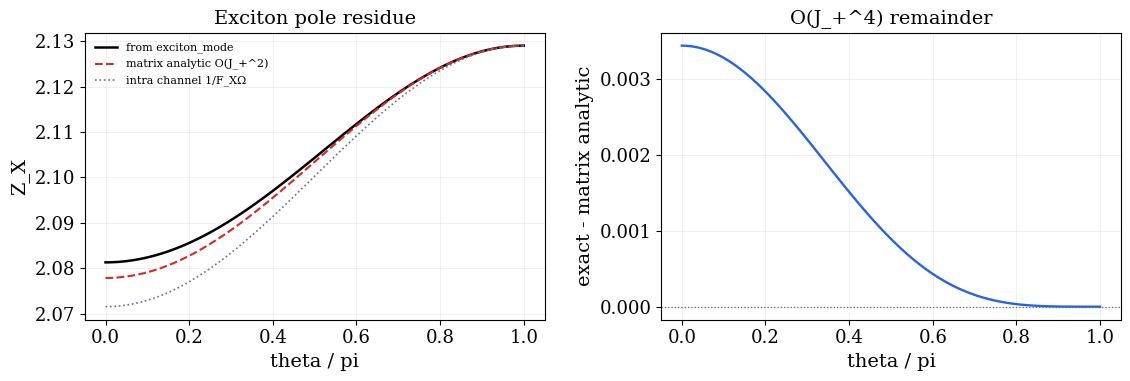

In [162]:
# -----------------------------
# Analytic small-J+ expansion of the exciton pole residue
# -----------------------------
function residue_expansion_coefficients()
    U = V_intra
    W = V_inter
    s = sqrt(γ_cv^2 + U^2)       # band-center distance at the AFM intralayer pole
    u = U^2

    # g(Ω; E_b) = -[(E_b + γ_cv - Ω)^2 - γ_cv^2]^(-1/2), evaluated at AFM.
    g = -1 / U
    gΩ = -s * u^(-3/2)
    gE = -gΩ
    gEE = u^(-3/2) - 3s^2 * u^(-5/2)
    gEEΩ = 9s * u^(-5/2) - 15s^3 * u^(-7/2)

    F0Ω = -gΩ
    F0ΩΩ = -gEE
    C0 = -1 / W - g
    C0Ω = -gΩ

    # Effective single-mode denominator:
    # F_X(Ω,J+) = F0(Ω) + J+^2 F2(Ω) + O(J+^4).
    F2 = -0.5 * gEE - gE^2 / C0
    gEΩ = -gEE
    F2Ω = -0.5 * gEEΩ - (2gE * gEΩ * C0 - gE^2 * C0Ω) / C0^2

    E2 = -F2 / F0Ω
    Zafm = 1 / F0Ω
    Z2 = -(F2Ω + E2 * F0ΩΩ) / F0Ω^2          # Schur: residue of D_ii = Z_X |<intra|X>|^2
    Z2m = Z2 + Zafm * (gE / C0)^2            # matrix residue: + channel projection ct = J+^2 (gE/C0)^2
    δZ = -Z2m * Jt_tot()^2

    return (; Zafm, Z2, Z2m, δZ, E2)
end

Zexp = residue_expansion_coefficients()
θsZ = collect(range(0.0, stop=π, length=101))
modeZ = [exciton_mode(θv) for θv in θsZ]
Z_exact = [m.Z for m in modeZ]
ct_exact = [abs2(m.X[2]) for m in modeZ]
Z_schur = [Zexp.Zafm + Zexp.Z2 * J_plus(θv)^2 for θv in θsZ]      # intra-channel residue 1/F_XΩ
Z_analytic = [Zexp.Zafm + Zexp.Z2m * J_plus(θv)^2 for θv in θsZ]  # matrix residue Z_X

@printf("Residue: Z_AFM = %.6f ; at FM: exact Z = %.6f, matrix analytic = %.6f, intra-channel 1/F_XΩ = %.6f\n",
        Zexp.Zafm, Z_exact[1], Z_analytic[1], Z_schur[1])
@printf("channel-projection check at FM: exact Z(1-ct) = %.6f  vs  1/F_XΩ analytic = %.6f\n",
        Z_exact[1] * (1 - ct_exact[1]), Z_schur[1])

fig, axs = subplots(1, 2, figsize=(11.5, 4.0))
axs[1].plot(θsZ ./ π, Z_exact, lw=1.8, color="black", label="from exciton_mode")
axs[1].plot(θsZ ./ π, Z_analytic, lw=1.5, ls="--", color="#dc2626", label="matrix analytic O(J_+^2)")
axs[1].plot(θsZ ./ π, Z_schur, lw=1.2, ls=":", color="#64748b", label="intra channel 1/F_XΩ")
axs[1].set_xlabel("theta / pi")
axs[1].set_ylabel("Z_X")
axs[1].set_title("Exciton pole residue")
axs[1].grid(alpha=0.18)
axs[1].legend(frameon=false, fontsize=8)

axs[2].plot(θsZ ./ π, Z_exact .- Z_analytic, lw=1.7, color="#2563eb")
axs[2].axhline(0.0, color="0.4", lw=0.9, ls=":")
axs[2].set_xlabel("theta / pi")
axs[2].set_ylabel("exact - matrix analytic")
axs[2].set_title("O(J_+^4) remainder")
axs[2].grid(alpha=0.18)

fig.tight_layout()

## Closed form of $E_X$ for all configurations

The mode is $\gtrsim99.7\%$ intralayer, so the exact pole can be expanded around the AFM point in the small sector coupling $J_+=J_t\cos(\theta/2)$ (so $J_+^2=J_t^2(1+x)/2$), with $J_t=J_{pd,c}+J_{pd,v}$. The structure is plain second-order perturbation theory on the pole:

1. **AFM anchor.** At $x=-1$ the two parity bands coincide and the bright exciton is the intralayer bound state sitting at depth
$$\bar\varepsilon\equiv\sqrt{\gamma_{cv}^2+V_{\rm intra}^2}$$
below the **center** of the electron-hole band:
$$E_X^{\rm AFM}=E_0+\gamma_{cv}-\bar\varepsilon.$$
2. **Perturbation.** $J_+$ shifts the two parity bands rigidly by $\mp J_+$; the first-order shift cancels by parity.
3. **Second order** has two contributions: the bound state's own response to the symmetric band shift (*continuum curvature*) and the level repulsion against the CT channel (*the $2\times2$ mechanism*).

The result is **linear in the overlap** $x=\mathbf M_1\cdot\mathbf M_2$:

$$\boxed{\;E_X(x)=E_X^{\rm AFM}-\frac{\Delta_B}{2}\,(1+x)+\mathcal O(J_+^4),\qquad \frac{dE_X}{dx}=-\frac{\Delta_B}{2},\;}$$

$$\Delta_B=
\underbrace{\frac{J_t^2}{2}\,\frac{3\bar\varepsilon^2-V_{\rm intra}^2}{\bar\varepsilon\,V_{\rm intra}^2}}_{\text{continuum curvature}}
\;+\;
\underbrace{\frac{J_t^2}{2\delta V}\cdot\frac{V_{\rm inter}\,\bar\varepsilon}{V_{\rm intra}^2}}_{\text{CT level repulsion}}.$$

**Relation to Heissenbuettel et al. (PRB 111, 075107).** Their minimal $2\times2$ BSE (our local sector Hamiltonian, $t_{e+h}B\leftrightarrow J_+$, $\Delta V_{eh}\leftrightarrow\delta V$) gives the simple coefficient $\Delta_B^{\rm loc}=J_t^2/(2\delta V)$. The CT term above is exactly $\Delta_B^{\rm loc}$ renormalized by the continuum factor $V_{\rm inter}\bar\varepsilon/V_{\rm intra}^2\simeq0.55$, while the curvature term has no counterpart in the $2\times2$ and in fact dominates here.

This makes the linear law *derived*, not fitted. Combined with Hellmann–Feynman it closes the whole single-mode response: $R^{(2D)}$ below needs **no numerics at all** — it is parametrized by the two optically measurable numbers $(E_X,\Delta_B)$, the same $\Delta_B^2$ structure as the density shift of arXiv:2409.18501.

In [163]:
# -----------------------------
# Closed-form E_X(x) and ΔB: evaluation and comparison with the exact root
# -----------------------------
δV = 0.5 * (V_intra - V_inter)
εbar = sqrt(γ_cv^2 + V_intra^2)            # exciton depth below the e-h band center
EX_AFM_closed = E0_pair() + γ_cv - εbar

ΔB_cont = Jt_tot()^2 / 2 * (3εbar^2 - V_intra^2) / (εbar * V_intra^2)
ΔB_loc  = Jt_tot()^2 / (2δV)                                # the 2x2 (paper) coefficient
ΔB_CT   = ΔB_loc * V_inter * εbar / V_intra^2               # ... continuum-renormalized
ΔB_closed = ΔB_cont + ΔB_CT

EX_closed(θ) = EX_AFM_closed - (ΔB_closed / 2) * (1 + cos(θ))

@printf("closed form: E_X(AFM) = %.5f eV ;  ΔB = %.2f meV  =  %.2f (continuum) + %.2f (CT)\n",
        EX_AFM_closed, 1e3*ΔB_closed, 1e3*ΔB_cont, 1e3*ΔB_CT)
@printf("2x2 (paper): ΔB_loc = %.2f meV ; continuum renormalization of CT term: %.3f\n",
        1e3*ΔB_loc, V_inter * εbar / V_intra^2)
@printf("exact root:  E_X(AFM) = %.5f eV ;  ΔB = %.2f meV\n",
        EX_and_slope(Float64(π)).EX, 1e3*ΔB)
@printf("coupling:    dE_X/dx = -ΔB/2 = %.2f meV (closed)  vs exact %.2f .. %.2f meV\n",
        -1e3*ΔB_closed/2, 1e3*EX_and_slope(0.0).dEXdx, 1e3*EX_and_slope(0.95π).dEXdx)

println("\n  θ/π     exact     closed    diff (meV)")
for t in (0.0, 0.25, 0.5, 0.75, 1.0)
    ex = EX_and_slope(t * π).EX
    cl = EX_closed(t * π)
    @printf("  %4.2f   %.5f   %.5f   %8.3f\n", t, ex, cl, 1e3*(cl - ex))
end
println("\nResidual error is the O(J+^4) truncation: exact at AFM (J+=0), largest at FM.")

closed form: E_X(AFM) = 1.35964 eV ;  ΔB = 15.35 meV  =  9.90 (continuum) + 5.45 (CT)
2x2 (paper): ΔB_loc = 9.83 meV ; continuum renormalization of CT term: 0.554
exact root:  E_X(AFM) = 1.35964 eV ;  ΔB = 14.99 meV
coupling:    dE_X/dx = -ΔB/2 = -7.67 meV (closed)  vs exact -7.33 .. -7.67 meV

  θ/π     exact     closed    diff (meV)
  0.00   1.34465   1.34430     -0.354
  0.25   1.34680   1.34654     -0.259
  0.50   1.35206   1.35197     -0.090
  0.75   1.35740   1.35740     -0.008
  1.00   1.35964   1.35964      0.000

Residual error is the O(J+^4) truncation: exact at AFM (J+=0), largest at FM.


## The two-$D$ term

Using $\Lambda_1^a=\Pi_x\,M_2^a$ and $\Lambda_2^b=\Pi_x\,M_1^b$, the channel trace pulls out of the spin structure with no extra factors:

$$R^{(2D),R}_{12,ab}(\Omega;\theta)=C_2\,M_2^a\,M_1^b\;K(\Omega),\qquad
K(\Omega)\equiv{\rm Tr}\left[D(\Omega)\,\Pi_x(\Omega)\,D(\Omega)\,\Pi_x(\Omega)\right]$$

with a real convention-dependent prefactor $C_2$; the plots below set $C_2=1$. For the layer pairs $(1,1)$ and $(2,2)$ the spin structure is $M_2^aM_2^b$ and $M_1^aM_1^b$ with the same kernel.

In the single-mode reduction $D\simeq Z_X|X\rangle\langle X|/(\Omega-E_X+i\eta)$, Hellmann–Feynman turns the kernel into a **double pole with the measured weight**:

$$K(\Omega)\simeq\frac{(dE_X/dx)^2}{(\Omega-E_X+i\eta)^2}\simeq\frac{(\Delta_B/2)^2}{(\Omega-E_X+i\eta)^2}.$$

A double pole is the response of a *shifting* level: the susceptibility senses $\partial E_X/\partial M$ twice; its lineshape is the frequency derivative of the single-pole one (dispersive). The wings carry single-pole corrections from the regular part of $D$ (CT pole and continuum), quantified below. Recall from the convention note that the off-mode part of the exact $K$ is singular exactly at $\theta=\pi$; the single-mode form is finite there.

θ=π/2: peak |K| exact=0.8959 at Ω=1.3515 ; single-mode=0.8777 ; ratio=1.0208


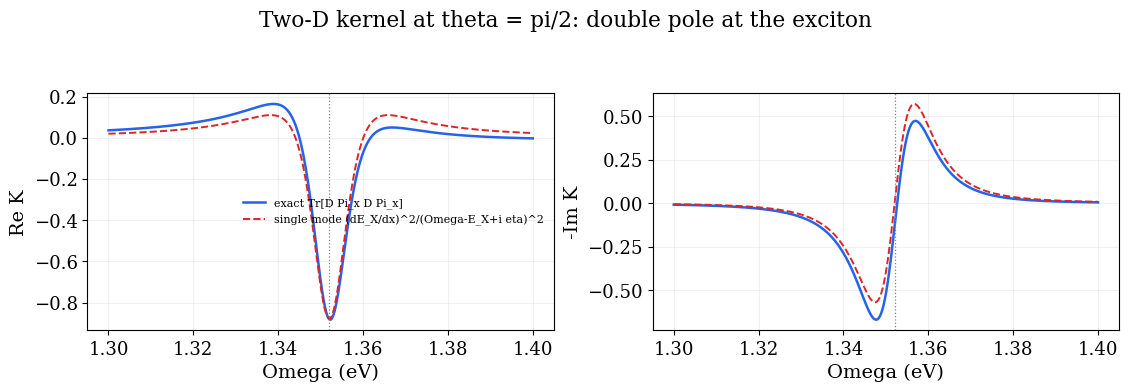

In [164]:
# -----------------------------
# Kernel K(Ω): exact channel trace vs single-mode double pole
# -----------------------------
function K_exact(d, Ω; η=ηΩ)
    D = inv(Vinv_s - Πs(d, Ω; η=η))
    P = Πx(d, Ω; η=η)
    return tr(D * P * D * P)
end

θK = π/2
modeK = exciton_mode(θK)
anK = EX_and_slope(θK)
ΩsK = collect(range(1.30, 1.40, length=801))
K_ex = ComplexF64[K_exact(modeK.data, Ω) for Ω in ΩsK]
K_sm = ComplexF64[anK.dEXdx^2 / (Ω - modeK.EX + 1im * ηΩ)^2 for Ω in ΩsK]

ipk = argmax(abs.(K_ex))
@printf("θ=π/2: peak |K| exact=%.4f at Ω=%.4f ; single-mode=%.4f ; ratio=%.4f\n",
        abs(K_ex[ipk]), ΩsK[ipk], maximum(abs.(K_sm)),
        abs(K_ex[ipk]) / maximum(abs.(K_sm)))

fig, axs = subplots(1, 2, figsize=(11.5, 4.0))
axs[1].plot(ΩsK, real.(K_ex), lw=1.8, color="#2563eb", label="exact Tr[D Pi_x D Pi_x]")
axs[1].plot(ΩsK, real.(K_sm), lw=1.4, ls="--", color="#dc2626", label="single mode (dE_X/dx)^2/(Omega-E_X+i eta)^2")
axs[1].axvline(modeK.EX, color="gray", lw=0.9, ls=":")
axs[1].set_xlabel("Omega (eV)")
axs[1].set_ylabel("Re K")
axs[1].grid(alpha=0.18)
axs[1].legend(frameon=false, fontsize=8)

axs[2].plot(ΩsK, -imag.(K_ex), lw=1.8, color="#2563eb")
axs[2].plot(ΩsK, -imag.(K_sm), lw=1.4, ls="--", color="#dc2626")
axs[2].axvline(modeK.EX, color="gray", lw=0.9, ls=":")
axs[2].set_xlabel("Omega (eV)")
axs[2].set_ylabel("-Im K")
axs[2].grid(alpha=0.18)

fig.suptitle("Two-D kernel at theta = pi/2: double pole at the exciton")
fig.tight_layout(rect=(0, 0, 1, 0.93))

## Retarded-response convention checks

A retarded susceptibility of Hermitian sources must satisfy three structural properties:

- **(R1)** $R(\Omega{=}0)$ is real (static response);
- **(R2)** $R(-\Omega)^*=R(\Omega)$ on the real axis, i.e. ${\rm Re}\,R$ even and ${\rm Im}\,R$ odd in $\Omega$;
- **(R3)** for a self-correlation (same operator — the *layer-diagonal* components), $-\,{\rm sgn}(\Omega)\,{\rm Im}\,R_{aa}(\Omega)\ge0$.

**The prefactor question is settled by the direct finite-difference validation below**: with the generating functional $\mathcal F=-\log\det[V^{-1}-\Pi(x)]$, the brute-force mixed derivative reproduces $R^{(1D)}+R^{(2D)}$ with **real** prefactors,

$$R^{(2D)}_{12,ab}=M_2^aM_1^b\,{\rm Tr}[D\Pi_xD\Pi_x],\qquad
R^{(1D)}_{12,ab}={\rm Tr}[D(\Pi_{xx}M_2^aM_1^b+\Pi_x\delta_{ab})],$$

to $\sim10^{-6}$. The lone $i$ of the inherited $R^{(II)}=i\,{\rm Tr}[D\Lambda D\Lambda]$ contour expression is absorbed by the loop measure: an $i$ prefactor would make $R(0)$ purely imaginary, violating (R1).

What the frequency-by-frequency kernel still lacks is **global** analytic structure: $\Pi$ (hence $D$, $K$) contains only the valence$\to$conduction block, so all poles sit at $\Omega>0$ — the resonant part. The completion consistent with (R1)–(R2) is $K(\Omega)+K(-\Omega)^*$, indistinguishable near the exciton (the anti-resonant tail there is $\sim10^{-5}$ of the pole, checked below).

Remaining caveats: the global constant linking $\mathcal F$ to the physically normalized susceptibility (and the $T=0$ occupation structure of the genuine Keldysh two-$D$ loop, relevant for pumped scenarios) still requires the contour derivation deferred in `StaticSpinSucep`; and (R3) constrains only the layer-diagonal **total** $R^{(1D)}+R^{(2D)}$.

In [165]:
# -----------------------------
# (R1)/(R2) checks on the kernel and its antiresonant completion
# -----------------------------
K0_conv = real(K_exact(modeK.data, 0.0; η=0.0))
@printf("(R1) static: real-prefactor convention: R(0) ∝ K(0) = %.4e  (real, OK)\n", K0_conv)
println("     an i prefactor would give i·K(0): purely imaginary -> fails (R1)")

Ωs_sym = collect(range(-2.5, 2.5, length=2001))
Kp_sym = ComplexF64[K_exact(modeK.data, Ω) for Ω in Ωs_sym]
viol_K = maximum(abs.(conj.(reverse(Kp_sym)) .- Kp_sym))
Kfull_sym = Kp_sym .+ conj.(reverse(Kp_sym))
viol_full = maximum(abs.(conj.(reverse(Kfull_sym)) .- Kfull_sym))
@printf("(R2) parity: max|K(-Ω)* - K(Ω)| = %.3f  (resonant part alone violates)\n", viol_K)
@printf("     completed K(Ω)+K(-Ω)*:       %.2e  (machine zero, OK)\n", viol_full)
iEXc = argmin(abs.(Ωs_sym .- modeK.EX))
@printf("antiresonant size at the pole: |K(-E_X)*|/|K(E_X)| = %.2e  (negligible near resonance)\n",
        abs(conj(K_exact(modeK.data, -modeK.EX))) / abs(Kp_sym[iEXc]))

(R1) static: real-prefactor convention: R(0) ∝ K(0) = 7.6800e-05  (real, OK)
     an i prefactor would give i·K(0): purely imaginary -> fails (R1)
(R2) parity: max|K(-Ω)* - K(Ω)| = 9.978  (resonant part alone violates)
     completed K(Ω)+K(-Ω)*:       0.00e+00  (machine zero, OK)
antiresonant size at the pole: |K(-E_X)*|/|K(E_X)| = 1.29e-05  (negligible near resonance)


## Angle dependence: coupling, spin structure, static kernel

Left: the coupling $dE_X/dx$ from the exact implicit slope — nearly the constant $-\Delta_B/2$ — and its torque (transverse) magnitude $|dE_X/dx|\sin\theta$ against the closed-form estimate $(\Delta_B/2)\sin\theta$. Middle: the nonzero components of the cross-layer spin structure $M_2^aM_1^b$ (the $y$ row/column vanishes in this coplanar geometry). Right: the static kernel $K(0)$ — the strength of the **exciton-mediated interlayer exchange** — exact vs single-mode $(dE_X/dx)^2/E_X^2$. The sweep stops just short of $\theta=\pi$, where the off-mode part of $\Pi_x$ is non-analytic (convention note above).

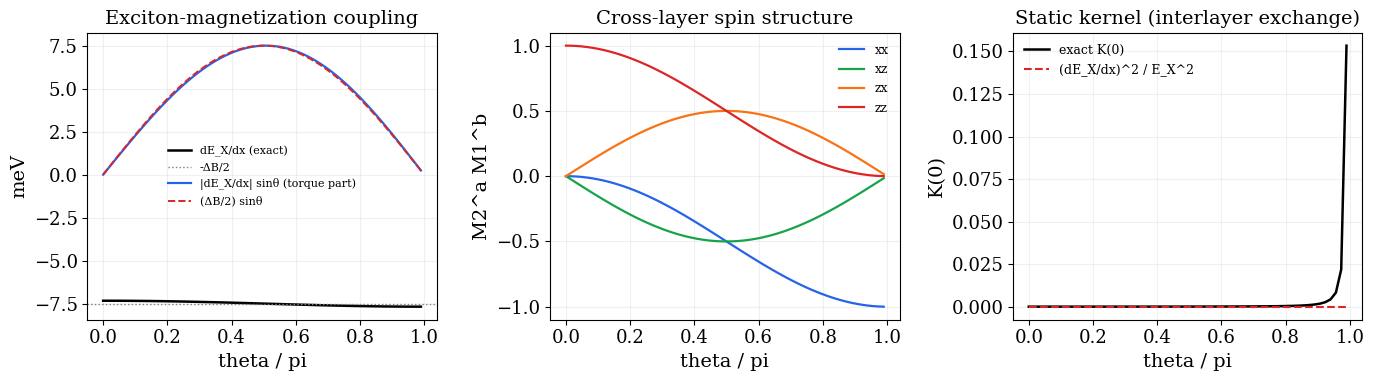

In [166]:
θs_sweep = collect(range(0.0, stop=0.99π, length=61))
slopes = [EX_and_slope(θ) for θ in θs_sweep]
dEdx = [s.dEXdx for s in slopes]
G_torque = [abs(s.dEXdx) * sin(θ) for (s, θ) in zip(slopes, θs_sweep)]
G_quad = [(ΔB / 2) * sin(θ) for θ in θs_sweep]

# cross-layer spin structure components M2^a M1^b (xx, xz, zx, zz)
tens = Dict("xx" => Float64[], "xz" => Float64[], "zx" => Float64[], "zz" => Float64[])
for θ in θs_sweep
    a = mhat2(θ); b = mhat1(θ)
    push!(tens["xx"], a[1] * b[1]); push!(tens["xz"], a[1] * b[3])
    push!(tens["zx"], a[3] * b[1]); push!(tens["zz"], a[3] * b[3])
end

# static kernel
K0_ex = Float64[]
K0_sm = Float64[]
for (s, θ) in zip(slopes, θs_sweep)
    d = sector_data(θ)
    push!(K0_ex, real(K_exact(d, 0.0; η=0.0)))
    push!(K0_sm, s.dEXdx^2 / s.EX^2)
end

fig, axs = subplots(1, 3, figsize=(14.0, 4.0))
axs[1].plot(θs_sweep ./ π, 1e3 .* dEdx, "-", lw=1.8, color="black", label="dE_X/dx (exact)")
axs[1].axhline(-1e3 * ΔB / 2, color="gray", lw=1.0, ls=":", label="-ΔB/2")
axs[1].plot(θs_sweep ./ π, 1e3 .* G_torque, "-", lw=1.6, color="#2563eb", label="|dE_X/dx| sinθ (torque part)")
axs[1].plot(θs_sweep ./ π, 1e3 .* G_quad, "--", lw=1.4, color="#dc2626", label="(ΔB/2) sinθ")
axs[1].set_xlabel("theta / pi")
axs[1].set_ylabel("meV")
axs[1].set_title("Exciton-magnetization coupling")
axs[1].grid(alpha=0.18)
axs[1].legend(frameon=false, fontsize=8)

for (lbl, col) in zip(("xx", "xz", "zx", "zz"), ("#2563eb", "#16a34a", "#f97316", "#dc2626"))
    axs[2].plot(θs_sweep ./ π, tens[lbl], lw=1.6, color=col, label=lbl)
end
axs[2].set_xlabel("theta / pi")
axs[2].set_ylabel("M2^a M1^b")
axs[2].set_title("Cross-layer spin structure")
axs[2].grid(alpha=0.18)
axs[2].legend(frameon=false, fontsize=9)

axs[3].plot(θs_sweep ./ π, K0_ex, "-", lw=1.8, color="black", label="exact K(0)")
axs[3].plot(θs_sweep ./ π, K0_sm, "--", lw=1.5, color="#dc2626", label="(dE_X/dx)^2 / E_X^2")
axs[3].set_xlabel("theta / pi")
axs[3].set_ylabel("K(0)")
axs[3].set_title("Static kernel (interlayer exchange)")
axs[3].grid(alpha=0.18)
axs[3].legend(frameon=false, fontsize=9)
fig.tight_layout()

## Full tensor: $R^{(2D)}_{12,ab}(\Omega)$ at $\theta=\pi/2$

The cross-layer ($l=1,l'=2$) response attaches the spin structure to the kernel,

$$R^{(2D),R}_{12,ab}(\Omega)=M_2^a\,M_1^b\,K(\Omega)$$

for the resonant positive-frequency part, with the real prefactor set to one. The panels show the nonzero components $ab=xx,xz,zz$ (at $\theta=\pi/2$: $M_2^xM_1^x=-\tfrac12$, $M_2^xM_1^z=-\tfrac12$, $M_2^zM_1^z=\tfrac12$), exact (solid) vs single-mode (dashed). The physical spectral plot $-2\,{\rm Im}\,R$ therefore follows $-2M_2^aM_1^b\,{\rm Im}\,K$ in this resonant approximation.

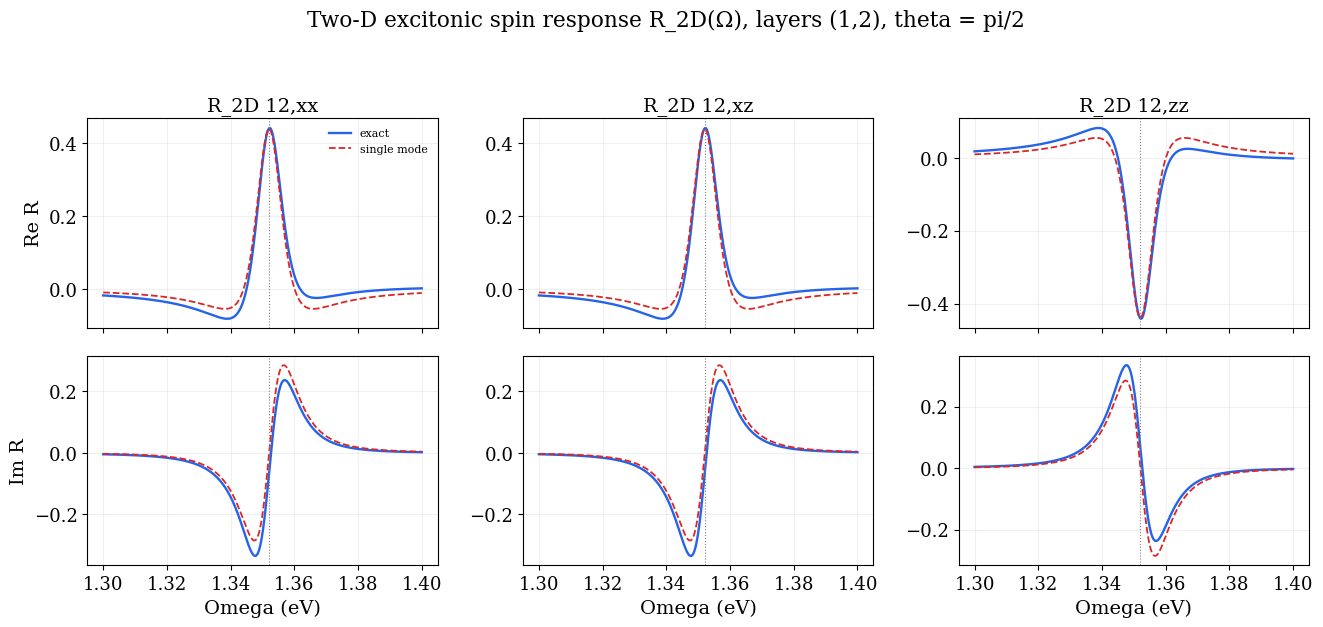

In [167]:
θR = π/2
M1R = mhat1(θR); M2R = mhat2(θR)
comps = [(1, 1, "xx"), (1, 3, "xz"), (3, 3, "zz")]

fig, axs = subplots(2, 3, figsize=(13.5, 6.4), sharex=true)
for (j, (a, b, lbl)) in enumerate(comps)
    geom = M2R[a] * M1R[b]
    R_ex = geom .* K_ex
    R_sm = geom .* K_sm

    axs[1, j].plot(ΩsK, real.(R_ex), lw=1.7, color="#2563eb", label="exact")
    axs[1, j].plot(ΩsK, real.(R_sm), lw=1.3, ls="--", color="#dc2626", label="single mode")
    axs[1, j].axvline(modeK.EX, color="gray", lw=0.8, ls=":")
    axs[1, j].set_title("R_2D 12," * lbl)
    axs[1, j].set_ylabel(j == 1 ? "Re R" : "")
    axs[1, j].grid(alpha=0.18)
    j == 1 && axs[1, j].legend(frameon=false, fontsize=8)

    axs[2, j].plot(ΩsK, imag.(R_ex), lw=1.7, color="#2563eb")
    axs[2, j].plot(ΩsK, imag.(R_sm), lw=1.3, ls="--", color="#dc2626")
    axs[2, j].axvline(modeK.EX, color="gray", lw=0.8, ls=":")
    axs[2, j].set_xlabel("Omega (eV)")
    axs[2, j].set_ylabel(j == 1 ? "Im R" : "")
    axs[2, j].grid(alpha=0.18)
end
fig.suptitle("Two-D excitonic spin response R_2D(Ω), layers (1,2), theta = pi/2")
fig.tight_layout(rect=(0, 0, 1, 0.94))

## Angle-resolved susceptibility components $R^{(2D)}_{12,ab}(\Omega,\theta)$

The angle dependence of each tensor component combines two factors:

$$-2\,{\rm Im}\,R^{(2D)}_{12,ab}(\Omega,\theta)=-2\,M_2^a(\theta)\,M_1^b(\theta)\,{\rm Im}\,K(\Omega;\theta),$$

- the **spin structure** $M_2^aM_1^b(\theta)$, which redistributes weight among components and flips signs ($xx\propto-\sin^2(\theta/2)$, $zz\propto\cos^2(\theta/2)$, $xz/zx\propto\mp\sin\theta/2$; the $y$ row/column vanishes in this coplanar geometry);
- the **kernel along the moving pole**: the double-pole dispersive structure rides on $E_X(\theta)=E_X^{\rm AFM}-\frac{\Delta_B}{2}(1+\cos\theta)$, with nearly constant weight $(\Delta_B/2)^2$.

In the single-mode form the maps are simply $-2M_2^aM_1^b\,{\rm Im}\,[(\Delta_B/2)^2/(\Omega-E_X(\theta)+i\eta)^2]$: a dispersive doublet of fixed strength tracing the exciton line, modulated by the spin-structure factors. The exact maps below (with $E_X(\theta)$ overlaid) test that picture component by component.

**Reading the AFM end.** Toward $\theta\to\pi$ the exact kernel acquires, on top of the double pole, an off-mode **single-pole** contribution whose weight grows like $1/c^2$ — the convention-note non-analyticity. It dominates the $xx$ panel near the AFM end (its spin factor $\to-1$ there, while $zz$ is protected by $\cos^2(\theta/2)\to0$). The color scale is therefore fixed by the $\theta\le0.8\pi$ physics and the near-AFM region is shown saturated; the unclipped maximum is printed for reference.

This divergence is a **diagram-level artifact, not physics**: the gauge-invariant exciton determinant depends on the off-diagonal bubble only through $\Pi_{ic}^2\propto(1+x)$, which is analytic in $x$, so the generating functional — and hence the *total* response $R^{(1D)}+R^{(2D)}$ — is smooth at AFM. The $1/c^2$ single pole of $R^{(2D)}$ must cancel against a matching divergence in the one-$D$ term, with the same $M_2^aM_1^b$ tensor structure. Verifying this cancellation explicitly is a built-in consistency check for the next stage.

map grid (321, 49) ; color scale ±2.19 (θ≤0.8π) ; unclipped max 27.5 at the AFM end


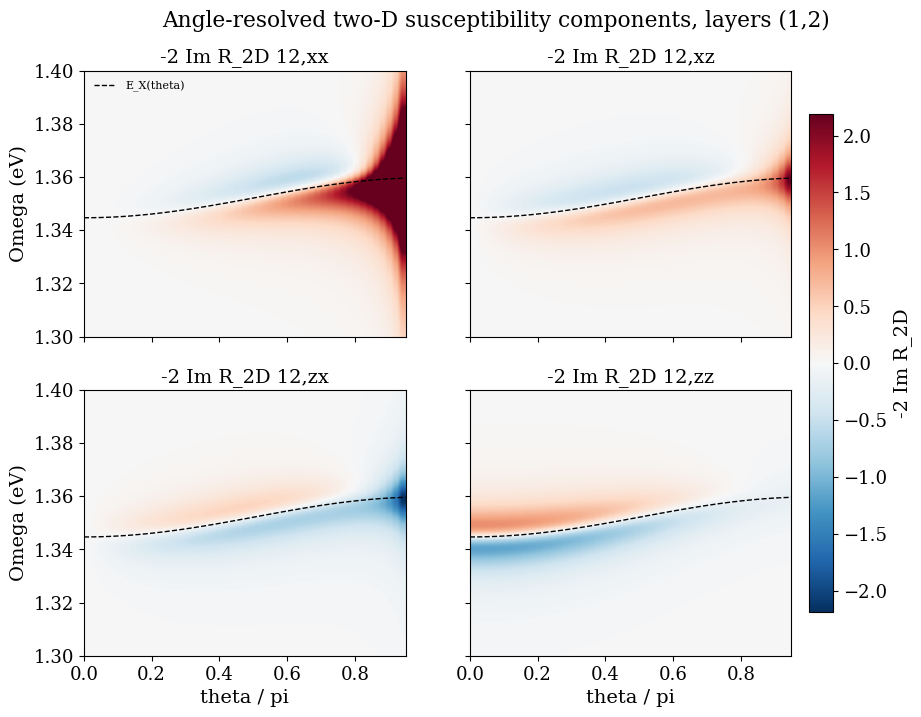

PyObject Text(0.5, 0.96, 'Angle-resolved two-D susceptibility components, layers (1,2)')

In [168]:
# -----------------------------
# Angle-resolved maps: -2 Im R_2D_{12,ab}(Ω, θ) for ab = xx, xz, zx, zz
# -----------------------------
θs_map = collect(range(0.0, stop=0.95π, length=49))
Ωs_map = collect(range(1.30, 1.40, length=321))

K_map = zeros(ComplexF64, length(Ωs_map), length(θs_map))
EX_line = zeros(length(θs_map))
for (iθ, θ) in enumerate(θs_map)
    dθ = sector_data(θ)
    EX_line[iθ] = EX_and_slope(θ).EX
    for (iΩ, Ω) in enumerate(Ωs_map)
        K_map[iΩ, iθ] = K_exact(dθ, Ω)
    end
end

comps_map = [(1, 1, "xx"), (1, 3, "xz"), (3, 1, "zx"), (3, 3, "zz")]
R_maps = [[-2 * mhat2(θs_map[iθ])[a] * mhat1(θs_map[iθ])[b] * imag(K_map[iΩ, iθ])
           for iΩ in eachindex(Ωs_map), iθ in eachindex(θs_map)]
          for (a, b, _) in comps_map]

# Color scale from the θ ≤ 0.8π physics: beyond that the off-mode 1/c part
# (convention-note artifact) grows without bound and would crush the scale;
# the near-AFM region is shown saturated on purpose.
iθ_scale = findlast(θs_map .<= 0.8π)
vmax_map = maximum(M -> maximum(abs, @view M[:, 1:iθ_scale]), R_maps)
vmax_true = maximum(M -> maximum(abs, M), R_maps)
@printf("map grid %s ; color scale ±%.2f (θ≤0.8π) ; unclipped max %.1f at the AFM end\n",
        string(size(K_map)), vmax_map, vmax_true)

fig, axs = subplots(2, 2, figsize=(11.0, 7.6), sharex=true, sharey=true)
axs_flat = vec(permutedims(axs))
extent_map = (θs_map[1] / π, θs_map[end] / π, Ωs_map[1], Ωs_map[end])
img = nothing
for (j, (a, b, lbl)) in enumerate(comps_map)
    ax = axs_flat[j]
    img = ax.imshow(R_maps[j], origin="lower", aspect="auto", extent=extent_map,
                    cmap="RdBu_r", vmin=-vmax_map, vmax=vmax_map)
    ax.plot(θs_map ./ π, EX_line, color="black", lw=1.0, ls="--", label="E_X(theta)")
    ax.set_title("-2 Im R_2D 12," * lbl)
    ax.grid(false)
end
for ax in axs[:, 1]
    ax.set_ylabel("Omega (eV)")
end
for ax in axs[end, :]
    ax.set_xlabel("theta / pi")
end
axs_flat[1].legend(frameon=false, fontsize=8, loc="upper left")
# NOTE: no tight_layout here -- it fights with a multi-axes colorbar and
# misplaces it; colorbar(ax=...) manages the space itself.
cbar = fig.colorbar(img, ax=vec(axs), shrink=0.85, pad=0.02)
cbar.set_label("-2 Im R_2D")
fig.suptitle("Angle-resolved two-D susceptibility components, layers (1,2)", y=0.96)

## The one-D term

The other Gaussian correction contains one exciton propagator and the two-magnetization vertex,

$$R^{(1D),R}_{ll',ab}(\Omega)=C_1\,\mathrm{Tr}\left[D^R(\Omega)\,\Lambda^{ll',ab}(\Omega)\right],$$

with a real convention-dependent prefactor; below we set $C_1=1$. In the overlap variable $x=\mathbf M_1\cdot\mathbf M_2$,

$$\Lambda^{12,ab}=\Pi_{xx}\,M_2^aM_1^b+\Pi_x\delta_{ab},$$

while

$$\Lambda^{11,ab}=\Pi_{xx}\,M_2^aM_2^b,\qquad
\Lambda^{22,ab}=\Pi_{xx}\,M_1^aM_1^b.$$

The single-mode version keeps only the bright pole in $D$:

$$R^{(1D),R}_{12,ab}(\Omega)\simeq
\frac{Z_X\langle X|\Pi_{xx}|X\rangle M_2^aM_1^b
+Z_X\langle X|\Pi_x|X\rangle\delta_{ab}}
{\Omega-E_X+i\eta}.$$

The second term is fixed by Hellmann-Feynman, $Z_X\langle X|\Pi_x|X\rangle=dE_X/dx\simeq-\Delta_B/2$.

In [169]:
# -----------------------------
# One-D term: second overlap derivative and contraction with one D
# -----------------------------
function Πcc(d, Ω; η=0.0)
    P = zeros(ComplexF64, 2, 2)
    for t in eachindex(d.ΔE)
        q = Ω + 1im * η - d.ΔE[t]
        c = 2 * d.occ[t] * d.dΔE[t]^2 / q^3
        @views P .+= c .* d.w[:, :, t]
    end
    return P ./ d.L
end

function Πxx(d, Ω; η=0.0)
    @assert abs(d.c) > 1e-10 "Πxx in x is singular exactly at AFM because c=sqrt((1+x)/2)."
    return Πcc(d, Ω; η=η) ./ (16 * d.c^2) .- Πc(d, Ω; η=η) ./ (16 * d.c^3)
end

function lambda_two_magnetization_overlap_parts(d, Ω, θ; layer_pair=(1, 2), η=ηΩ)
    Px = Πx(d, Ω; η=η)
    Pxx = Πxx(d, Ω; η=η)
    M1 = mhat1(θ)
    M2 = mhat2(θ)
    l, lp = layer_pair
    Λxx = zeros(ComplexF64, 3, 3, 2, 2)
    Λx = zeros(ComplexF64, 3, 3, 2, 2)

    for a in 1:3, b in 1:3
        if l == 1 && lp == 1
            Λxx[a, b, :, :] .= M2[a] * M2[b] .* Pxx
        elseif l == 2 && lp == 2
            Λxx[a, b, :, :] .= M1[a] * M1[b] .* Pxx
        elseif l == 1 && lp == 2
            Λxx[a, b, :, :] .= M2[a] * M1[b] .* Pxx
            a == b && (Λx[a, b, :, :] .= Px)
        elseif l == 2 && lp == 1
            Λxx[a, b, :, :] .= M1[a] * M2[b] .* Pxx
            a == b && (Λx[a, b, :, :] .= Px)
        else
            error("layer_pair must be (1,1), (1,2), (2,1), or (2,2)")
        end
    end
    return (; curvature=Λxx, geometric=Λx, total=Λxx .+ Λx)
end

function lambda_two_magnetization_overlap(d, Ω, θ; layer_pair=(1, 2), η=ηΩ)
    return lambda_two_magnetization_overlap_parts(d, Ω, θ; layer_pair=layer_pair, η=η).total
end

function contract_R1D_matrix(D, Λ; prefactor=1.0)
    R = zeros(ComplexF64, 3, 3)
    for a in 1:3, b in 1:3
        R[a, b] = prefactor * tr(D * Matrix(@view Λ[a, b, :, :]))
    end
    return R
end

function R1D_exact_parts(d, Ω, θ; layer_pair=(1, 2), η=ηΩ, prefactor=1.0)
    D = inv(Vinv_s - Πs(d, Ω; η=η))
    Λparts = lambda_two_magnetization_overlap_parts(d, Ω, θ; layer_pair=layer_pair, η=η)
    Rcurv = contract_R1D_matrix(D, Λparts.curvature; prefactor=prefactor)
    Rgeom = contract_R1D_matrix(D, Λparts.geometric; prefactor=prefactor)
    return (; curvature=Rcurv, geometric=Rgeom, total=Rcurv .+ Rgeom)
end

function R1D_exact(d, Ω, θ; layer_pair=(1, 2), η=ηΩ, prefactor=1.0)
    return R1D_exact_parts(d, Ω, θ; layer_pair=layer_pair, η=η, prefactor=prefactor).total
end

function R1D_single_mode_parts(mode, Ω, θ; layer_pair=(1, 2), η=ηΩ, prefactor=1.0)
    X = mode.X
    d = mode.data
    Ax = mode.Z * (X' * Πx(d, mode.EX) * X)
    Axx = mode.Z * (X' * Πxx(d, mode.EX) * X)
    M1 = mhat1(θ)
    M2 = mhat2(θ)
    l, lp = layer_pair
    denom = Ω - mode.EX + 1im * η
    Rcurv = zeros(ComplexF64, 3, 3)
    Rgeom = zeros(ComplexF64, 3, 3)

    for a in 1:3, b in 1:3
        if l == 1 && lp == 1
            Rcurv[a, b] = Axx * M2[a] * M2[b]
        elseif l == 2 && lp == 2
            Rcurv[a, b] = Axx * M1[a] * M1[b]
        elseif l == 1 && lp == 2
            Rcurv[a, b] = Axx * M2[a] * M1[b]
            a == b && (Rgeom[a, b] = Ax)
        elseif l == 2 && lp == 1
            Rcurv[a, b] = Axx * M1[a] * M2[b]
            a == b && (Rgeom[a, b] = Ax)
        else
            error("layer_pair must be (1,1), (1,2), (2,1), or (2,2)")
        end
    end

    Rcurv = prefactor .* Rcurv ./ denom
    Rgeom = prefactor .* Rgeom ./ denom
    return (; curvature=Rcurv, geometric=Rgeom, total=Rcurv .+ Rgeom)
end

function R1D_single_mode(mode, Ω, θ; layer_pair=(1, 2), η=ηΩ, prefactor=1.0)
    return R1D_single_mode_parts(mode, Ω, θ; layer_pair=layer_pair, η=η, prefactor=prefactor).total
end

# Chain-rule check: Π_xx against a finite difference of Π_x in x=cosθ.
let θ0 = 0.6π, δ = 2e-5, Ωt = 1.34
    x0 = cos(θ0)
    fd = (Πx(sector_data(acos(x0 + δ)), Ωt) .- Πx(sector_data(acos(x0 - δ)), Ωt)) ./ (2δ)
    an = Πxx(sector_data(θ0), Ωt)
    @printf("chain-rule check max|∂²Π/∂x² (FD) - Π_xx| = %.2e\n", maximum(abs.(fd .- an)))
end

chain-rule check max|∂²Π/∂x² (FD) - Π_xx| = 6.56e-12


## One-D split: common data

The one-D vertex has two independent pieces,

$$
\Lambda^{12,ab}=\underbrace{\Pi_{xx}M_2^aM_1^b}_{\text{curvature part}}
+\underbrace{\Pi_x\delta_{ab}}_{\text{geometric part}}.
$$

This cell only prepares the shared angle, frequency grid, and exact/single-mode arrays. The following cells plot each piece separately.


In [170]:
θ1D = π/2
layer_pair1D = (1, 2)
mode1D = exciton_mode(θ1D)
d1D = mode1D.data
Ωs1D = collect(range(1.30, 1.40, length=801))

R1D_ex_parts = [R1D_exact_parts(d1D, Ω, θ1D; layer_pair=layer_pair1D, η=ηΩ) for Ω in Ωs1D]
R1D_sm_parts = [R1D_single_mode_parts(mode1D, Ω, θ1D; layer_pair=layer_pair1D, η=ηΩ) for Ω in Ωs1D]

Ax1D = real(mode1D.Z * (mode1D.X' * Πx(d1D, mode1D.EX) * mode1D.X))
Axx1D = real(mode1D.Z * (mode1D.X' * Πxx(d1D, mode1D.EX) * mode1D.X))
@printf("One-D projected weights at θ=π/2: Z<X|Πx|X> = %.4f meV, Z<X|Πxx|X> = %.4f meV\n",
        1e3 * Ax1D, 1e3 * Axx1D)

comps1D = [(1, 1, "xx"), (2, 2, "yy"), (1, 3, "xz"), (3, 3, "zz")]


One-D projected weights at θ=π/2: Z<X|Πx|X> = -7.4952 meV, Z<X|Πxx|X> = 1.2268 meV


4-element Vector{Tuple{Int64, Int64, String}}:
 (1, 1, "xx")
 (2, 2, "yy")
 (1, 3, "xz")
 (3, 3, "zz")

## One-D curvature contribution

This is the part coming from the explicit second derivative of the polarization channel,

$$
R^{(1D),R}_{\rm curv} = C_1\,\mathrm{Tr}\left[D^R(\Omega)\,\Pi_{xx}(\Omega)M_2^aM_1^b\right].
$$

It carries the spin-geometry factors, so it can appear in mixed components such as $xz$.


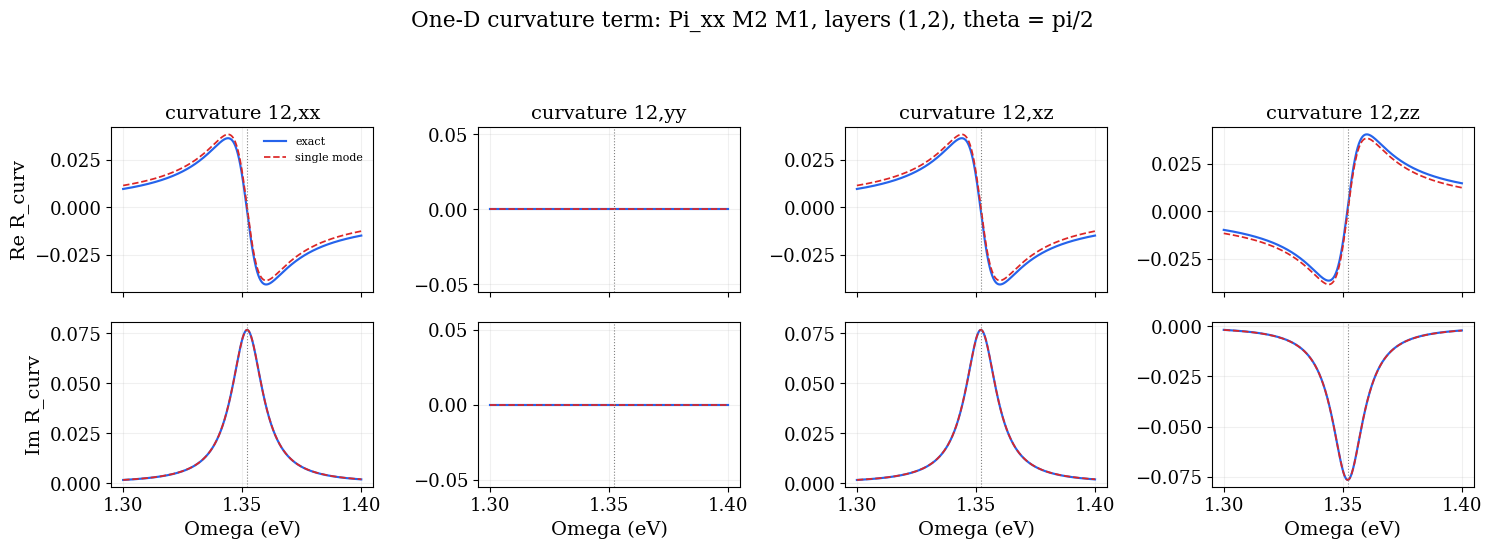

In [171]:
fig, axs = subplots(2, length(comps1D), figsize=(15.0, 5.6), sharex=true)
for (j, (a, b, lbl)) in enumerate(comps1D)
    yre_ex = [real(R.curvature[a, b]) for R in R1D_ex_parts]
    yim_ex = [imag(R.curvature[a, b]) for R in R1D_ex_parts]
    yre_sm = [real(R.curvature[a, b]) for R in R1D_sm_parts]
    yim_sm = [imag(R.curvature[a, b]) for R in R1D_sm_parts]

    axs[1, j].plot(Ωs1D, yre_ex, lw=1.55, color="#2563eb", label="exact")
    axs[1, j].plot(Ωs1D, yre_sm, lw=1.25, ls="--", color="#dc2626", label="single mode")
    axs[2, j].plot(Ωs1D, yim_ex, lw=1.55, color="#2563eb")
    axs[2, j].plot(Ωs1D, yim_sm, lw=1.25, ls="--", color="#dc2626")

    for ax in axs[:, j]
        ax.axvline(mode1D.EX, color="gray", lw=0.8, ls=":")
        ax.grid(alpha=0.18)
    end
    axs[1, j].set_title("curvature 12," * lbl)
    axs[2, j].set_xlabel("Omega (eV)")
end
axs[1, 1].set_ylabel("Re R_curv")
axs[2, 1].set_ylabel("Im R_curv")
axs[1, 1].legend(frameon=false, fontsize=8)
fig.suptitle("One-D curvature term: Pi_xx M2 M1, layers (1,2), theta = pi/2")
fig.tight_layout(rect=(0, 0, 1, 0.92))


## One-D geometric contribution

This is the cross-layer metric term from differentiating the overlap itself,

$$
R^{(1D),R}_{\rm geom} = C_1\,\mathrm{Tr}\left[D^R(\Omega)\,\Pi_x(\Omega)\delta_{ab}\right].
$$

For layers $(1,2)$ it is nonzero only for diagonal spin components $a=b$; in this coplanar geometry the $yy$ panel isolates this term cleanly.


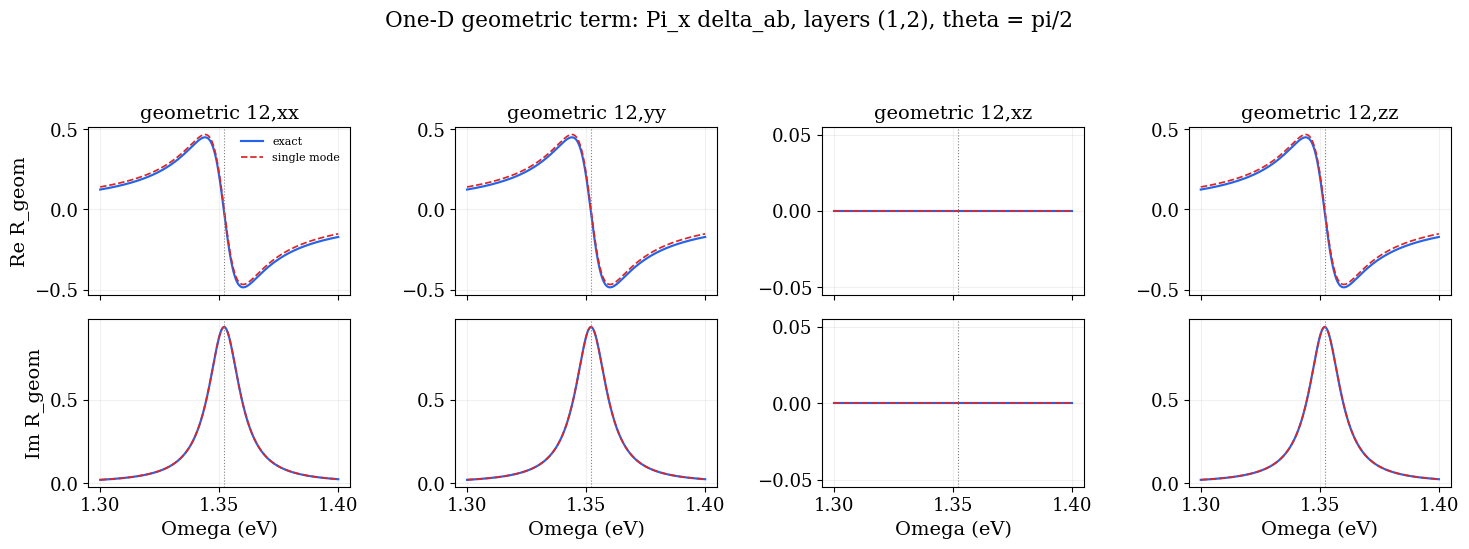

In [172]:
fig, axs = subplots(2, length(comps1D), figsize=(15.0, 5.6), sharex=true)
for (j, (a, b, lbl)) in enumerate(comps1D)
    yre_ex = [real(R.geometric[a, b]) for R in R1D_ex_parts]
    yim_ex = [imag(R.geometric[a, b]) for R in R1D_ex_parts]
    yre_sm = [real(R.geometric[a, b]) for R in R1D_sm_parts]
    yim_sm = [imag(R.geometric[a, b]) for R in R1D_sm_parts]

    axs[1, j].plot(Ωs1D, yre_ex, lw=1.55, color="#2563eb", label="exact")
    axs[1, j].plot(Ωs1D, yre_sm, lw=1.25, ls="--", color="#dc2626", label="single mode")
    axs[2, j].plot(Ωs1D, yim_ex, lw=1.55, color="#2563eb")
    axs[2, j].plot(Ωs1D, yim_sm, lw=1.25, ls="--", color="#dc2626")

    for ax in axs[:, j]
        ax.axvline(mode1D.EX, color="gray", lw=0.8, ls=":")
        ax.grid(alpha=0.18)
    end
    axs[1, j].set_title("geometric 12," * lbl)
    axs[2, j].set_xlabel("Omega (eV)")
end
axs[1, 1].set_ylabel("Re R_geom")
axs[2, 1].set_ylabel("Im R_geom")
axs[1, 1].legend(frameon=false, fontsize=8)
fig.suptitle("One-D geometric term: Pi_x delta_ab, layers (1,2), theta = pi/2")
fig.tight_layout(rect=(0, 0, 1, 0.92))


## Cancellation with the two-D term

There is an important cancellation in the part proportional to $M_2^aM_1^b$. With the present sign convention,

$$
R^{(2D),R}_{12,ab}=M_2^aM_1^b\,\mathrm{Tr}\left[D^R\Pi_xD^R\Pi_x\right],
\qquad
R^{(1D),R}_{\rm curv,12,ab}=M_2^aM_1^b\,\mathrm{Tr}\left[D^R\Pi_{xx}\right].
$$

Near the bright pole, their singular combination is

$$
R^{(2D),R}_{12,ab}+R^{(1D),R}_{\rm curv,12,ab}
\simeq M_2^aM_1^b\left[
\frac{(\partial_xE_X)^2}{(\Omega-E_X+i\eta)^2}
+\frac{\partial_x^2E_X}{\Omega-E_X+i\eta}\right].
$$

So the pole-simple pieces cancel only if $E_X(x)$ is exactly linear. In the full band calculation $E_X(x)$ has a small curvature, so the cancellation is strong but not exact. The geometric term $\Pi_x\delta_{ab}$ is not part of this cancellation; it is the contact term from differentiating the overlap itself.


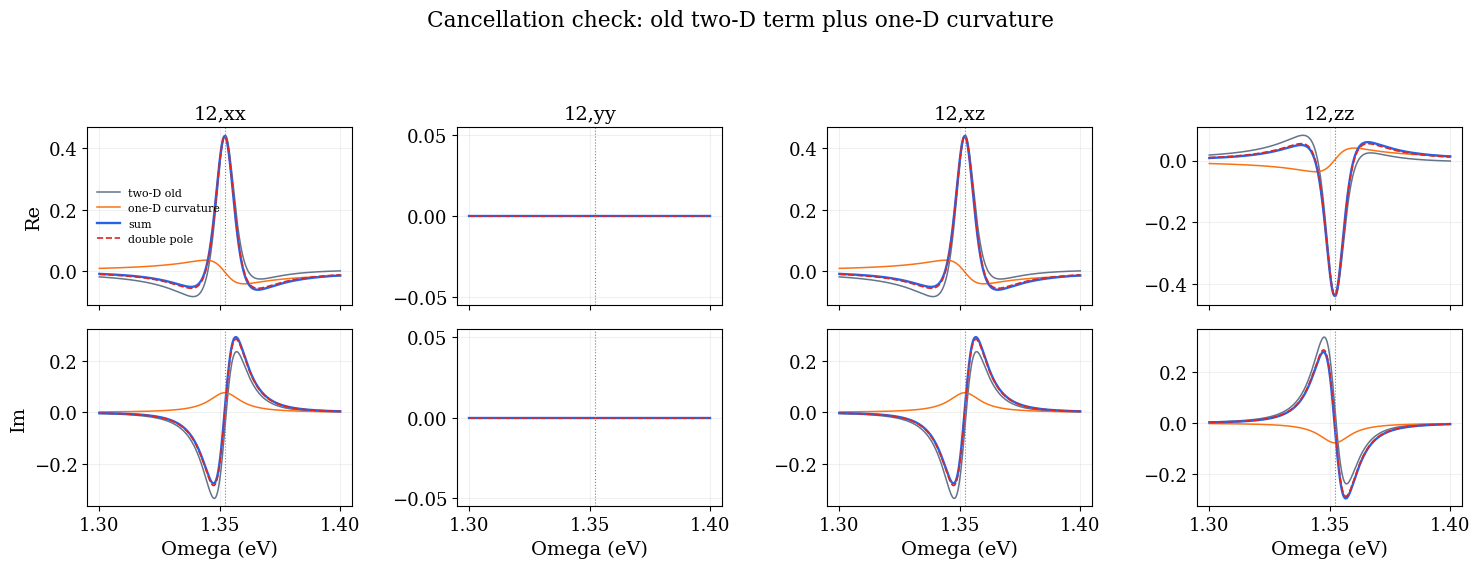

In [173]:
function R2D_overlap_exact(d, Ω, θ; η=ηΩ)
    K = K_exact(d, Ω; η=η)
    M1 = mhat1(θ)
    M2 = mhat2(θ)
    return [M2[a] * M1[b] * K for a in 1:3, b in 1:3]
end

function R2D_overlap_single_mode(mode, Ω, θ; η=ηΩ)
    dEdx = real(mode.Z * (mode.X' * Πx(mode.data, mode.EX) * mode.X))
    q = Ω - mode.EX + 1im * η
    M1 = mhat1(θ)
    M2 = mhat2(θ)
    return [M2[a] * M1[b] * dEdx^2 / q^2 for a in 1:3, b in 1:3]
end

R2D_ex_1D = [R2D_overlap_exact(d1D, Ω, θ1D; η=ηΩ) for Ω in Ωs1D]
R2D_sm_1D = [R2D_overlap_single_mode(mode1D, Ω, θ1D; η=ηΩ) for Ω in Ωs1D]
Rcurv_plus_R2D = [R2D_ex_1D[i] .+ R1D_ex_parts[i].curvature for i in eachindex(Ωs1D)]

fig, axs = subplots(2, length(comps1D), figsize=(15.0, 5.8), sharex=true)
for (j, (a, b, lbl)) in enumerate(comps1D)
    yold_re = [real(R[a, b]) for R in R2D_ex_1D]
    ycurv_re = [real(R.curvature[a, b]) for R in R1D_ex_parts]
    ysum_re = [real(R[a, b]) for R in Rcurv_plus_R2D]
    ypole_re = [real(R[a, b]) for R in R2D_sm_1D]

    yold_im = [imag(R[a, b]) for R in R2D_ex_1D]
    ycurv_im = [imag(R.curvature[a, b]) for R in R1D_ex_parts]
    ysum_im = [imag(R[a, b]) for R in Rcurv_plus_R2D]
    ypole_im = [imag(R[a, b]) for R in R2D_sm_1D]

    axs[1, j].plot(Ωs1D, yold_re, lw=1.1, color="#64748b", label="two-D old")
    axs[1, j].plot(Ωs1D, ycurv_re, lw=1.1, color="#f97316", label="one-D curvature")
    axs[1, j].plot(Ωs1D, ysum_re, lw=1.7, color="#2563eb", label="sum")
    axs[1, j].plot(Ωs1D, ypole_re, lw=1.2, ls="--", color="#dc2626", label="double pole")

    axs[2, j].plot(Ωs1D, yold_im, lw=1.1, color="#64748b")
    axs[2, j].plot(Ωs1D, ycurv_im, lw=1.1, color="#f97316")
    axs[2, j].plot(Ωs1D, ysum_im, lw=1.7, color="#2563eb")
    axs[2, j].plot(Ωs1D, ypole_im, lw=1.2, ls="--", color="#dc2626")

    for ax in axs[:, j]
        ax.axvline(mode1D.EX, color="gray", lw=0.8, ls=":")
        ax.grid(alpha=0.18)
    end
    axs[1, j].set_title("12," * lbl)
    axs[2, j].set_xlabel("Omega (eV)")
end
axs[1, 1].set_ylabel("Re")
axs[2, 1].set_ylabel("Im")
axs[1, 1].legend(frameon=false, fontsize=8)
fig.suptitle("Cancellation check: old two-D term plus one-D curvature")
fig.tight_layout(rect=(0, 0, 1, 0.92))


## Pole-coefficient check

This cell checks the cancellation directly by fitting the scalar kernels near the exciton pole as

$$
y(\Omega)=\frac{A}{q^2}+\frac{B}{q}+C+Dq+\cdots,
\qquad q=\Omega-E_X+i\eta.
$$

The sum should keep the double-pole coefficient $A\simeq(\partial_xE_X)^2$, while the remaining simple-pole coefficient should be $B\simeq\partial_x^2E_X$.


In [174]:
function scalar_curvature_kernel(d, Ω; η=ηΩ)
    D = inv(Vinv_s - Πs(d, Ω; η=η))
    return tr(D * Πxx(d, Ω; η=η))
end

function pole_coefficients(Ωs, ys, EX; η=ηΩ)
    q = Ωs .- EX .+ 1im * η
    Afit = hcat(1 ./ q.^2, 1 ./ q, ones(length(q)), q, q.^2)
    return Afit \ ys
end

function exciton_energy_from_x(x)
    @assert -1.0 <= x <= 1.0 "x = M1·M2 outside physical range; a clamp here would silently corrupt FD stencils"
    return exciton_mode(acos(x)).EX
end

δx_fit = 0.025
@assert abs(cos(θ1D)) + δx_fit <= 1.0 "FD stencil for d²E_X/dx² must stay inside |x| ≤ 1"
EX0_fit = mode1D.EX
Ωs_fit = collect(range(EX0_fit - 0.02, EX0_fit + 0.02, length=401))
old_fit = ComplexF64[K_exact(d1D, Ω; η=ηΩ) for Ω in Ωs_fit]
curv_fit = ComplexF64[scalar_curvature_kernel(d1D, Ω; η=ηΩ) for Ω in Ωs_fit]
co_old = pole_coefficients(Ωs_fit, old_fit, EX0_fit; η=ηΩ)
co_curv = pole_coefficients(Ωs_fit, curv_fit, EX0_fit; η=ηΩ)
co_sum = pole_coefficients(Ωs_fit, old_fit .+ curv_fit, EX0_fit; η=ηΩ)

x1D = cos(θ1D)
EX_xx_fd = (exciton_energy_from_x(x1D + δx_fit) - 2EX0_fit + exciton_energy_from_x(x1D - δx_fit)) / δx_fit^2
EX_x_fit = real(mode1D.Z * (mode1D.X' * Πx(d1D, EX0_fit) * mode1D.X))

@printf("Pole fit at θ=π/2:\n")
@printf("  A_sum = %.6e eV^2 ; (dE_X/dx)^2 = %.6e eV^2\n", real(co_sum[1]), EX_x_fit^2)
@printf("  B_old = %.4f meV, B_curv = %.4f meV, B_sum = %.4f meV\n",
        1e3 * real(co_old[2]), 1e3 * real(co_curv[2]), 1e3 * real(co_sum[2]))
@printf("  finite-difference d²E_X/dx² = %.4f meV\n", 1e3 * EX_xx_fd)


Pole fit at θ=π/2:
  A_sum = 5.617749e-05 eV^2 ; (dE_X/dx)^2 = 5.617749e-05 eV^2
  B_old = -1.0541 meV, B_curv = 1.2268 meV, B_sum = 0.1726 meV
  finite-difference d²E_X/dx² = 0.1726 meV


## Direct finite-difference response

Here the mixed spin derivative is evaluated directly by finite differences of the full excitonic functional,

$$
\mathcal F^R(\Omega,\mathbf M_1,\mathbf M_2)
=-\log\det\left[V^{-1}-\Pi^R(\Omega,\mathbf M_1\cdot\mathbf M_2)\right].
$$

No term is separated in the finite-difference calculation. The perturbation changes the two Cartesian components $M_1^a$ and $M_2^b$ independently, using the extension $\mathcal F^R=\mathcal F^R(\mathbf M_1\cdot\mathbf M_2)$; therefore the contact term proportional to $\delta_{ab}$ is included automatically.

The red dotted reference applies the same finite-difference procedure to the linear analytic exciton pole. In that reference $\partial_x^2E_X=0$; diagonal components can still contain the contact response from $\delta_{ab}\partial_x\mathcal F^R$.


direct finite-difference check: max |FD full - explicit total| = 3.743e-06


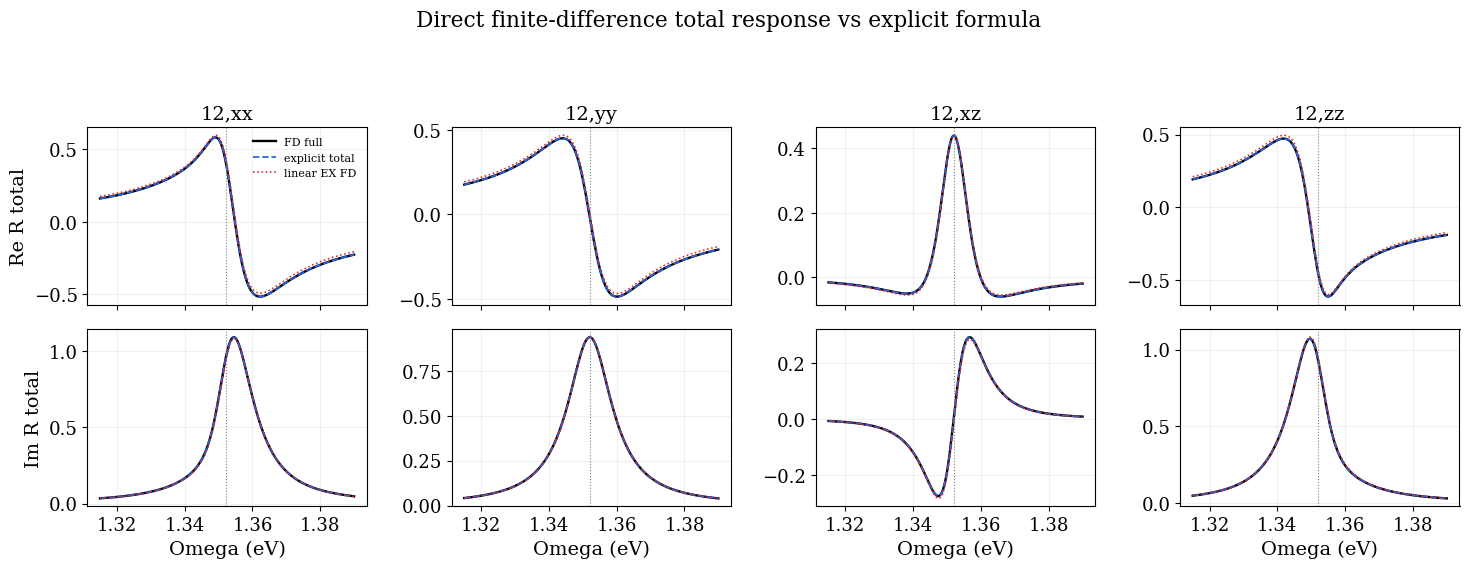

In [175]:
fd_cache = Dict{Tuple{Float64, Float64, Float64}, ComplexF64}()

function exciton_logdet_kernel(Ω, x; η=ηΩ)
    xc = clamp(x, -0.999999999, 0.999999999)
    key = (Ω, round(xc; digits=12), η)
    return get!(fd_cache, key) do
        d = sector_data(acos(xc))
        -log(det(Vinv_s - Πs(d, Ω; η=η)))
    end
end

EX_AFM_linear = EX_and_slope(Float64(π)).EX
slope_linear = -ΔB / 2

function linear_logdet_kernel(Ω, x; η=ηΩ)
    EX_linear = EX_AFM_linear + slope_linear * (x + 1)
    return -log(Ω - EX_linear + 1im * η)
end

function mixed_component_fd(kernel, Ω, θ, a, b; δ=2e-3, η=ηΩ)
    M1 = mhat1(θ)
    M2 = mhat2(θ)
    x0 = dot(M1, M2)
    xshift(du, dv) = x0 + du * M2[a] + dv * M1[b] + (a == b ? du * dv : 0.0)
    return (kernel(Ω, xshift( δ,  δ); η=η)
          - kernel(Ω, xshift( δ, -δ); η=η)
          - kernel(Ω, xshift(-δ,  δ); η=η)
          + kernel(Ω, xshift(-δ, -δ); η=η)) / (4δ^2)
end

δ_fd = 2e-3
Ωs_fd = collect(range(1.315, 1.390, length=181))
R_formula_total_fd = [R2D_overlap_exact(d1D, Ω, θ1D; η=ηΩ) .+
                      R1D_exact_parts(d1D, Ω, θ1D; layer_pair=layer_pair1D, η=ηΩ).total
                      for Ω in Ωs_fd]
R_fd_full = [[mixed_component_fd(exciton_logdet_kernel, Ω, θ1D, a, b; δ=δ_fd, η=ηΩ)
              for Ω in Ωs_fd]
             for (a, b, _) in comps1D]
R_fd_linear = [[mixed_component_fd(linear_logdet_kernel, Ω, θ1D, a, b; δ=δ_fd, η=ηΩ)
                for Ω in Ωs_fd]
               for (a, b, _) in comps1D]

max_fd_error = maximum([maximum(abs.(R_fd_full[j] .- [R[a, b] for R in R_formula_total_fd]))
                        for (j, (a, b, _)) in enumerate(comps1D)])
@printf("direct finite-difference check: max |FD full - explicit total| = %.3e\n", max_fd_error)

fig, axs = subplots(2, length(comps1D), figsize=(15.0, 5.8), sharex=true)
for (j, (a, b, lbl)) in enumerate(comps1D)
    y_formula = [R[a, b] for R in R_formula_total_fd]
    y_fd = R_fd_full[j]
    y_lin = R_fd_linear[j]

    axs[1, j].plot(Ωs_fd, real.(y_fd), lw=1.7, color="black", label="FD full")
    axs[1, j].plot(Ωs_fd, real.(y_formula), lw=1.25, ls="--", color="#2563eb", label="explicit total")
    axs[1, j].plot(Ωs_fd, real.(y_lin), lw=1.15, ls=":", color="#dc2626", label="linear EX FD")

    axs[2, j].plot(Ωs_fd, imag.(y_fd), lw=1.7, color="black")
    axs[2, j].plot(Ωs_fd, imag.(y_formula), lw=1.25, ls="--", color="#2563eb")
    axs[2, j].plot(Ωs_fd, imag.(y_lin), lw=1.15, ls=":", color="#dc2626")

    for ax in axs[:, j]
        ax.axvline(mode1D.EX, color="gray", lw=0.8, ls=":")
        ax.grid(alpha=0.18)
    end
    axs[1, j].set_title("12," * lbl)
    axs[2, j].set_xlabel("Omega (eV)")
end
axs[1, 1].set_ylabel("Re R total")
axs[2, 1].set_ylabel("Im R total")
axs[1, 1].legend(frameon=false, fontsize=8)
fig.suptitle("Direct finite-difference total response vs explicit formula")
fig.tight_layout(rect=(0, 0, 1, 0.92))


## Final contributing terms

After the cancellation, the old two-D kernel and the one-D curvature term should not be interpreted as independent simple-pole contributions. In the analytic linear-exciton approximation,

$$
E_X(x)=E_X^{AFM}+g_X(x+1),
\qquad g_X\equiv \partial_x E_X=-\frac{\Delta_B}{2},
\qquad q=\Omega-E_X(x)+i\eta,
$$

so $\partial_x^2E_X=0$. The only singular terms left in the excitonic spin response are

$$
R^{X,R}_{12,ab}(\Omega)
\simeq
M_2^aM_1^b\,\frac{g_X^2}{q^2}
+\delta_{ab}\,\frac{g_X}{q}.
$$

Thus off-diagonal spin components receive only the double-pole term, while diagonal components also contain the contact term from differentiating $x=\mathbf M_1\cdot\mathbf M_2$. In the full band calculation one can keep the small nonlinearity as

$$
R^{X,R}_{12,ab}(\Omega)
\simeq
M_2^aM_1^b\left[\frac{(\partial_xE_X)^2}{q^2}+\frac{\partial_x^2E_X}{q}\right]
+\delta_{ab}\frac{\partial_xE_X}{q},
$$

and the last $\partial_x^2E_X$ term is the residual measured in the pole-coefficient check above.


## Angle sweep of the final contributing terms

The two physical pieces of the excitonic spin response are mapped separately over $(\Omega,\theta)$ and then summed. In exact form they are the **smooth** combinations

$$K_{\rm pole}(\Omega;\theta)\equiv{\rm Tr}[D\Pi_xD\Pi_x]+{\rm Tr}[D\Pi_{xx}]
\;\;\big(\text{spin structure }M_2^aM_1^b\big),\qquad
K_{\rm cont}(\Omega;\theta)\equiv{\rm Tr}[D\Pi_x]
\;\;\big(\text{spin structure }\delta_{ab}\big),$$

with single-mode forms $K_{\rm pole}\simeq g_X^2/q^2+(\partial_x^2E_X)/q$ and $K_{\rm cont}\simeq g_X/q$, $g_X=-\Delta_B/2$, $q=\Omega-E_X(\theta)+i\eta$.

Because the $1/c^2$ divergences cancel **inside** $K_{\rm pole}$ (pole-coefficient check above), both kernels are smooth all the way to the AFM end — unlike the raw two-$D$ maps, no color-scale clipping is needed and the sweep can run to $\theta\to\pi$. The shared kernels are computed once here and used by the three figures below.

In [176]:
# -----------------------------
# Shared kernels for the final-term maps
# -----------------------------
θs_fin = collect(range(0.0, stop=0.99π, length=49))
Ωs_fin = collect(range(1.30, 1.40, length=321))

K_pole_map = zeros(ComplexF64, length(Ωs_fin), length(θs_fin))
K_cont_map = zeros(ComplexF64, length(Ωs_fin), length(θs_fin))
EX_fin = zeros(length(θs_fin))
for (iθ, θ) in enumerate(θs_fin)
    dθ = sector_data(θ)
    EX_fin[iθ] = EX_and_slope(θ).EX
    for (iΩ, Ω) in enumerate(Ωs_fin)
        D = inv(Vinv_s - Πs(dθ, Ω; η=ηΩ))
        Px = Πx(dθ, Ω; η=ηΩ)
        K_pole_map[iΩ, iθ] = tr(D * Px * D * Px) + tr(D * Πxx(dθ, Ω; η=ηΩ))
        K_cont_map[iΩ, iθ] = tr(D * Px)
    end
end

comps_fin = [(1, 1, "xx"), (2, 2, "yy"), (1, 3, "xz"), (3, 3, "zz")]
extent_fin = (θs_fin[1] / π, θs_fin[end] / π, Ωs_fin[1], Ωs_fin[end])

# spin-structure factors per component and angle
geom_pole(a, b, iθ) = mhat2(θs_fin[iθ])[a] * mhat1(θs_fin[iθ])[b]
geom_cont(a, b) = (a == b ? 1.0 : 0.0)

function final_term_maps(which)
    maps = Vector{Matrix{Float64}}()
    for (a, b, _) in comps_fin
        M = zeros(length(Ωs_fin), length(θs_fin))
        for iθ in eachindex(θs_fin), iΩ in eachindex(Ωs_fin)
            v = 0.0 + 0.0im
            (which == :pole || which == :sum) && (v += geom_pole(a, b, iθ) * K_pole_map[iΩ, iθ])
            (which == :cont || which == :sum) && (v += geom_cont(a, b) * K_cont_map[iΩ, iθ])
            M[iΩ, iθ] = -2 * imag(v)
        end
        push!(maps, M)
    end
    return maps
end

function plot_final_maps(maps, title)
    fig, axs = subplots(2, 2, figsize=(11.0, 7.6), sharex=true, sharey=true)
    axs_flat = vec(permutedims(axs))
    vmax = maximum(M -> maximum(abs, M), maps)
    img = nothing
    for (j, (a, b, lbl)) in enumerate(comps_fin)
        ax = axs_flat[j]
        img = ax.imshow(maps[j], origin="lower", aspect="auto", extent=extent_fin,
                        cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.plot(θs_fin ./ π, EX_fin, color="black", lw=1.0, ls="--", label="E_X(theta)")
        ax.set_title("-2 Im R 12," * lbl)
        ax.grid(false)
    end
    for ax in axs[:, 1]
        ax.set_ylabel("Omega (eV)")
    end
    for ax in axs[end, :]
        ax.set_xlabel("theta / pi")
    end
    axs_flat[1].legend(frameon=false, fontsize=8, loc="upper left")
    cbar = fig.colorbar(img, ax=vec(axs), shrink=0.85, pad=0.02)
    cbar.set_label("-2 Im R")
    fig.suptitle(title, y=0.96)
    return fig
end

println("final-term kernels computed: ", size(K_pole_map), " ; smooth to θ = 0.99π (no clipping needed)")

final-term kernels computed: (321, 49) ; smooth to θ = 0.99π (no clipping needed)


### Double-pole term ($M_2^aM_1^b$ structure)

The shifting-level response: weight $g_X^2=(\Delta_B/2)^2$ riding the exciton line, with the small $\partial_x^2E_X$ simple-pole remainder. Sign pattern set by $M_2^aM_1^b(\theta)$; the $yy$ panel vanishes identically.

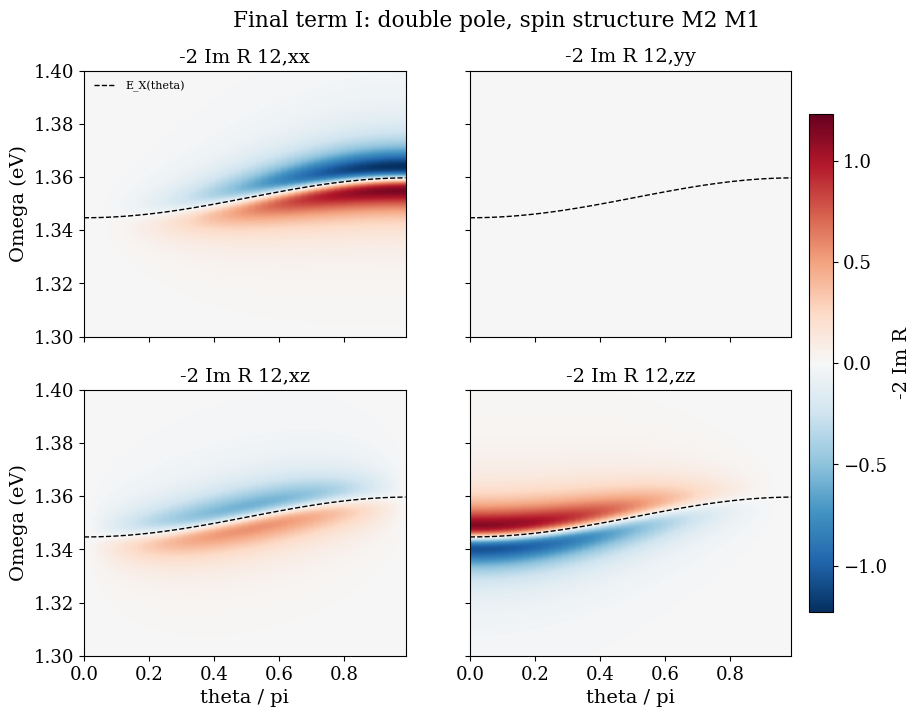

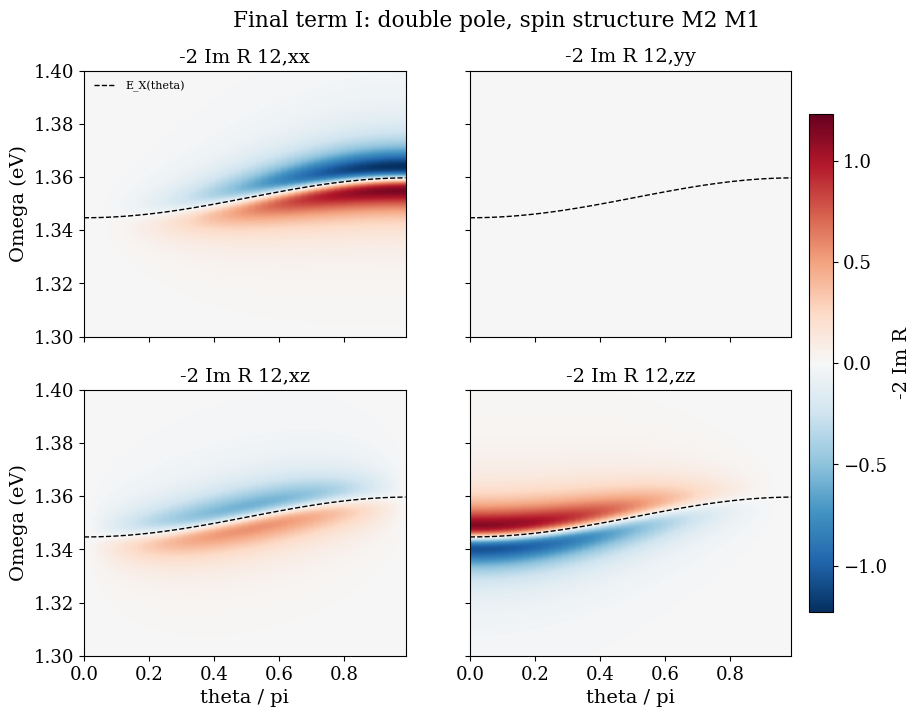

In [154]:
plot_final_maps(final_term_maps(:pole), "Final term I: double pole, spin structure M2 M1")

### Contact term ($\delta_{ab}$ structure)

The simple pole $g_X/q$ from differentiating the overlap itself, identical for all diagonal spin components and absent off-diagonal — the $yy$ panel isolates it cleanly (identical to $xx$ and $zz$ here), and the $xz$ panel vanishes.

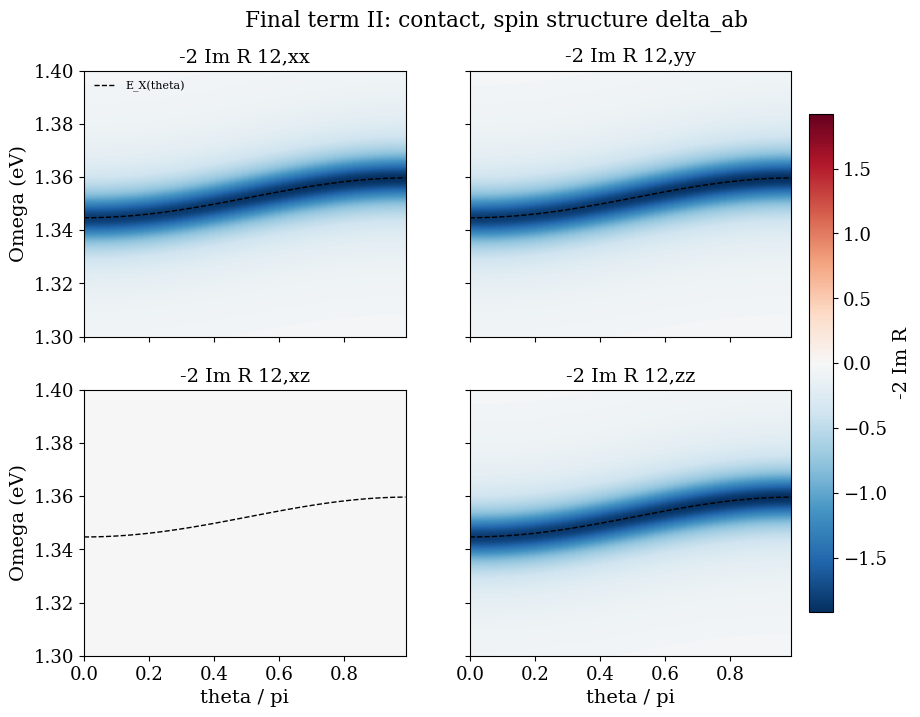

In [156]:
plot_final_maps(final_term_maps(:cont), "Final term II: contact, spin structure delta_ab")
plt.show()

### Total excitonic response

The sum of both terms — the complete $R^{X}_{12,ab}(\Omega,\theta)$ validated against the direct finite difference. Diagonal components mix the antisymmetric double-pole doublet with the contact Lorentzian; $xz$ stays pure double pole; $yy$ stays pure contact.

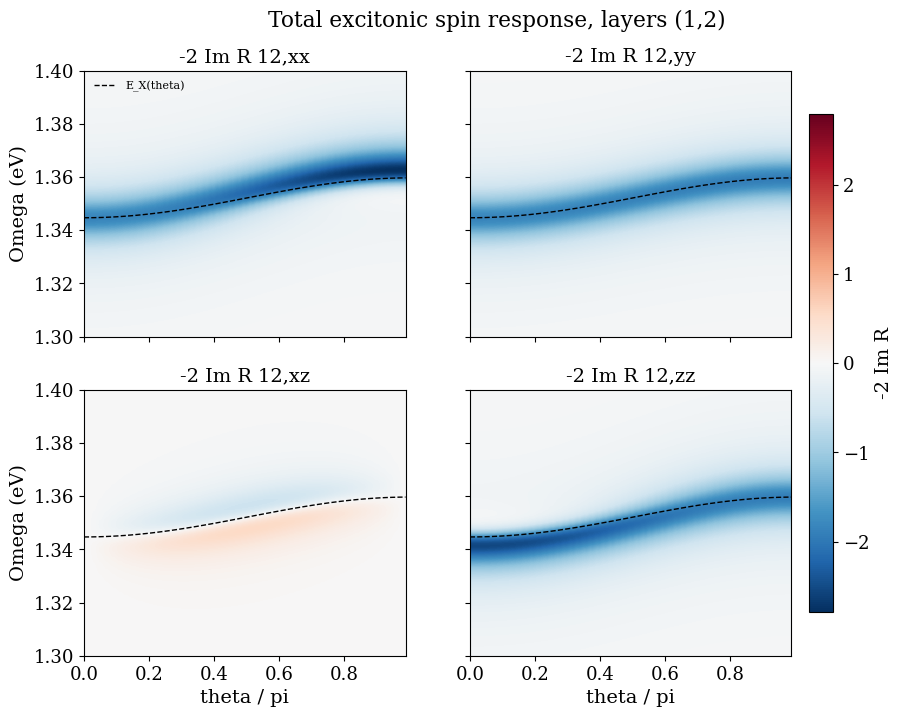

In [158]:
plot_final_maps(final_term_maps(:sum), "Total excitonic spin response, layers (1,2)")
plt.show()

## Slow-spin moments: exchange, damping, inertia

The effective field on the moments is the memory integral $h_l^a(t)=\int dt'\,R^{ab}_{ll'}(t-t')\,M_{l'}^b(t')$. Expanding the slow spin, $M(t-\tau)\simeq M(t)-\tau\dot M(t)+\tfrac{\tau^2}{2}\ddot M(t)$ (the Sayad–Potthoff expansion used in `StaticSpinSucep`),

$$h(t)\simeq J\,M(t)-\alpha\,\dot M(t)+\mathcal I\,\ddot M(t),$$

with the moments given by the **completed** retarded kernel $K_{\rm full}(\Omega)=K(\Omega)+K(-\Omega)^*$ (properties (R1)–(R2) guarantee they are real):

$$J=K_{\rm full}(0),\qquad
\alpha=\int_0^\infty\!\tau R(\tau)\,d\tau={\rm Im}\,\partial_\Omega K_{\rm full}\big|_0,\qquad
\mathcal I=\tfrac12\!\int_0^\infty\!\tau^2R(\tau)\,d\tau=-\tfrac12\,\partial_\Omega^2 K_{\rm full}\big|_0.$$

Each spin-structure channel gets its own scalar moments, $\alpha_{12,ab}=M_2^aM_1^b\,\alpha_{\rm pole}+\delta_{ab}\,\alpha_{\rm cont}$, etc. The single-mode closed forms ($g_X=-\Delta_B/2$, all per the global constant $C$):

$$\boxed{\;\alpha_{\rm cont}=\frac{2\eta\,\Delta_B}{E_X^3},\qquad
\alpha_{\rm pole}=\frac{3\eta\,\Delta_B^2}{E_X^4},\qquad
J_{\rm cont}=\frac{\Delta_B}{E_X},\qquad J_{\rm pole}=\frac{\Delta_B^2}{2E_X^2},\qquad
\mathcal I_{\rm cont}=-\frac{\Delta_B}{E_X^3},\qquad \mathcal I_{\rm pole}=-\frac{3\Delta_B^2}{2E_X^4}.\;}$$

Two physical conclusions:

1. **$\alpha\propto\eta$**: a gapped *virtual* exciton produces no intrinsic Gilbert damping — only the reactive exchange $J$ and inertia $\mathcal I$. Dissipation enters solely through the exciton linewidth: the channel is magnon $\to$ virtual exciton $\to$ exciton decay. Here $\eta$ stops being a numerical broadening and becomes the physical exciton lifetime ($\sim$ meV in CrSBr). Under pumping (real exciton population) this changes qualitatively — the Keldysh occupation structure deferred earlier.
2. The **contact channel dominates** ($\alpha_{\rm cont}/\alpha_{\rm pole}\sim 2E_X/3\Delta_B\approx60$) and carries $\delta_{ab}$ **between layers**: nearly isotropic *non-local* damping — exciton-mediated spin pumping from one layer to the other.

**Quantitative caveat** (verified below): at $\Omega=0$ the bright pole does *not* dominate the trace — the static moments integrate the whole excitonic spectrum (CT pole + continuum), and the exact values come out smaller than the single-mode forms ($\sim\times\tfrac12$ for $\alpha_{\rm cont}$, $\sim\times\tfrac16$ for $J_{\rm cont}$). Use the closed forms for scaling and mechanism, the exact trace for numbers. The LLG damping constant additionally needs the torque projection and $\gamma/M_s$ normalization.

In [177]:
# -----------------------------
# Slow-spin moments from the completed kernels: η scan at θ = π/2
# -----------------------------
Kpole_res(d, Ω; η=ηΩ) = K_exact(d, Ω; η=η) + scalar_curvature_kernel(d, Ω; η=η)
Kcont_res(d, Ω; η=ηΩ) = tr(inv(Vinv_s - Πs(d, Ω; η=η)) * Πx(d, Ω; η=η))
Kfull_of(Kres, d, Ω; η=ηΩ) = Kres(d, Ω; η=η) + conj(Kres(d, -Ω; η=η))

function slow_spin_moments(Kres, d; η=ηΩ, δΩ=1e-3)
    K0 = Kfull_of(Kres, d, 0.0; η=η)
    Kp = Kfull_of(Kres, d, δΩ; η=η)
    Km = Kfull_of(Kres, d, -δΩ; η=η)
    J = real(K0)
    α = imag((Kp - Km) / (2δΩ))
    I = -real(Kp - 2K0 + Km) / (2δΩ^2)
    return (; J, α, I)
end

θmom = π/2
dmom = sector_data(θmom)
gXm = EX_and_slope(θmom).dEXdx
EXm = EX_and_slope(θmom).EX

println("η scan at θ = π/2  (closed single-mode forms in parentheses):")
@printf("%8s | %11s %11s | %11s %11s | %11s %11s\n",
        "η (eV)", "α_cont", "(closed)", "α_pole", "(closed)", "J_cont", "(closed)")
for η in (0.002, 0.004, 0.008, 0.016)
    mc = slow_spin_moments(Kcont_res, dmom; η=η)
    mp = slow_spin_moments(Kpole_res, dmom; η=η)
    @printf("%8.3f | %11.4e %11.4e | %11.4e %11.4e | %11.4e %11.4e\n",
            η, mc.α, -4η * gXm / EXm^3, mp.α, 12η * gXm^2 / EXm^4, mc.J, -2gXm / EXm)
end
mc = slow_spin_moments(Kcont_res, dmom; η=ηΩ)
mp = slow_spin_moments(Kpole_res, dmom; η=ηΩ)
@printf("\ninertia at η = %.3f:  I_cont = %.4e (closed %.4e)   I_pole = %.4e (closed %.4e)\n",
        ηΩ, mc.I, 2gXm / EXm^3, mp.I, -6gXm^2 / EXm^4)
@printf("damping linearity check: α(2η)/α(η) = %.4f (cont), %.4f (pole)  [expect 2]\n",
        slow_spin_moments(Kcont_res, dmom; η=0.016).α / slow_spin_moments(Kcont_res, dmom; η=0.008).α,
        slow_spin_moments(Kpole_res, dmom; η=0.016).α / slow_spin_moments(Kpole_res, dmom; η=0.008).α)

η scan at θ = π/2  (closed single-mode forms in parentheses):
  η (eV) |      α_cont    (closed) |      α_pole    (closed) |      J_cont    (closed)
   0.002 |  1.2454e-05  2.4260e-05 |  8.5424e-08  4.0345e-07 |  1.8910e-03  1.1087e-02
   0.004 |  2.4907e-05  4.8519e-05 |  1.7084e-07  8.0690e-07 |  1.8910e-03  1.1087e-02
   0.008 |  4.9810e-05  9.7038e-05 |  3.4164e-07  1.6138e-06 |  1.8908e-03  1.1087e-02
   0.016 |  9.9591e-05  1.9408e-04 |  6.8288e-07  3.2276e-06 |  1.8902e-03  1.1087e-02

inertia at η = 0.008:  I_cont = -3.1125e-03 (closed -6.0649e-03)   I_pole = -2.1344e-05 (closed -1.0086e-04)
damping linearity check: α(2η)/α(η) = 1.9994 (cont), 1.9988 (pole)  [expect 2]


### Angle dependence of the moments

The scalar moments vary with $\theta$ only through the kernels (the pole position $E_X(\theta)$ moves by $\Delta_B\ll E_X$, so the variation is weak); the tensor structure carries the angular physics:

$$\alpha_{12,ab}(\theta)=M_2^a(\theta)M_1^b(\theta)\,\alpha_{\rm pole}(\theta)+\delta_{ab}\,\alpha_{\rm cont}(\theta),$$

and likewise for $J$ and $\mathcal I$. Left/middle: exact $\alpha_{\rm cont}$, $\alpha_{\rm pole}$ vs the closed forms. Right: exchange moments. The second figure shows the resulting damping-tensor components: the dominant contact piece makes $\alpha_{xx}\simeq\alpha_{yy}\simeq\alpha_{zz}$ nearly isotropic and $\theta$-flat, with the small $M_2M_1$ anisotropy on top (and a tiny $xz$ component from the pole term alone).

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


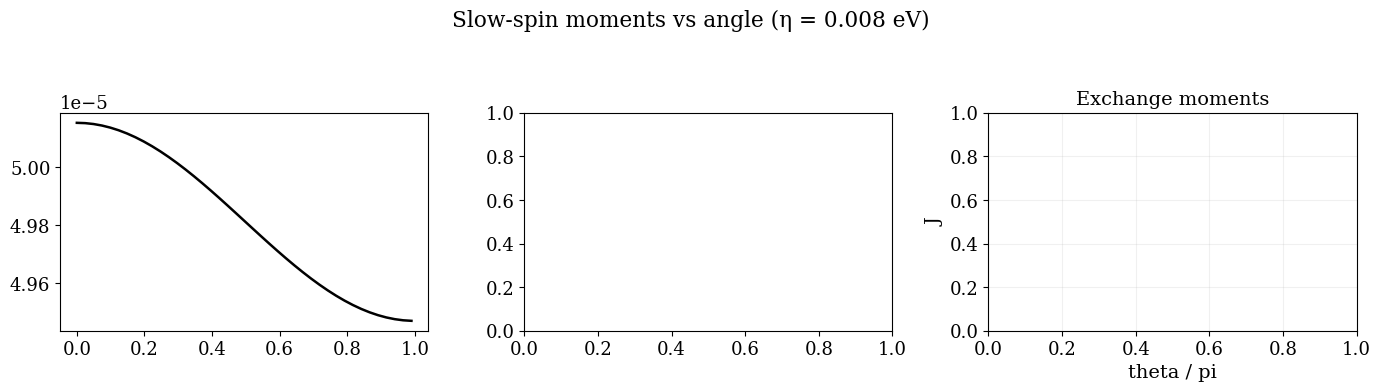

In [182]:
# -----------------------------
# θ sweep of the slow-spin moments
# -----------------------------
θs_mom = collect(range(0.0, stop=0.99π, length=41))
mom_cont = Vector{Any}(undef, length(θs_mom))
mom_pole = Vector{Any}(undef, length(θs_mom))
gX_mom = zeros(length(θs_mom))
EX_mom = zeros(length(θs_mom))
for (iθ, θ) in enumerate(θs_mom)
    dθ = sector_data(θ)
    mom_cont[iθ] = slow_spin_moments(Kcont_res, dθ; η=ηΩ)
    mom_pole[iθ] = slow_spin_moments(Kpole_res, dθ; η=ηΩ)
    s = EX_and_slope(θ)
    gX_mom[iθ] = s.dEXdx
    EX_mom[iθ] = s.EX
end

fig, axs = subplots(1, 3, figsize=(14.0, 4.0))
axs[1].plot(θs_mom ./ π, [m.α for m in mom_cont], lw=1.8, color="black", label="exact")
# axs[1].plot(θs_mom ./ π, -4ηΩ .* gX_mom ./ EX_mom.^3, lw=1.4, ls="--", color="#dc2626", label="closed 2ηΔB/E_X³")
# axs[1].set_xlabel("theta / pi"); axs[1].set_ylabel("alpha_cont")
# axs[1].set_title("Contact damping")
# axs[1].grid(alpha=0.18); axs[1].legend(frameon=false, fontsize=8)

# axs[2].plot(θs_mom ./ π, [m.α for m in mom_pole], lw=1.8, color="black", label="exact")
# axs[2].plot(θs_mom ./ π, 12ηΩ .* gX_mom.^2 ./ EX_mom.^4, lw=1.4, ls="--", color="#dc2626", label="closed 3ηΔB²/E_X⁴")
# axs[2].set_xlabel("theta / pi"); axs[2].set_ylabel("alpha_pole")
# axs[2].set_title("Pole damping")
# axs[2].grid(alpha=0.18); axs[2].legend(frameon=false, fontsize=8)

# axs[3].plot(θs_mom ./ π, [m.J for m in mom_cont], lw=1.8, color="black", label="J_cont exact")
# axs[3].plot(θs_mom ./ π, -2 .* gX_mom ./ EX_mom, lw=1.4, ls="--", color="#dc2626", label="closed ΔB/E_X")
# axs[3].plot(θs_mom ./ π, [m.J for m in mom_pole], lw=1.6, color="#2563eb", label="J_pole exact")
axs[3].set_xlabel("theta / pi"); axs[3].set_ylabel("J")
axs[3].set_title("Exchange moments")
axs[3].grid(alpha=0.18); axs[3].legend(frameon=false, fontsize=8)
fig.suptitle("Slow-spin moments vs angle (η = " * string(ηΩ) * " eV)")
fig.tight_layout(rect=(0, 0, 1, 0.93))

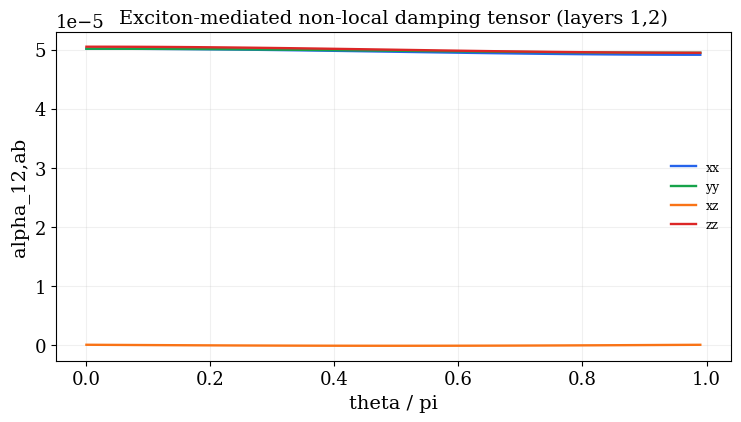

In [183]:
# -----------------------------
# Damping-tensor components α_{12,ab}(θ)
# -----------------------------
fig, ax = subplots(figsize=(7.6, 4.6))
for (a, b, lbl, col) in [(1,1,"xx","#2563eb"), (2,2,"yy","#16a34a"), (1,3,"xz","#f97316"), (3,3,"zz","#dc2626")]
    αab = [mhat2(θ)[a] * mhat1(θ)[b] * mom_pole[iθ].α + (a == b ? mom_cont[iθ].α : 0.0)
           for (iθ, θ) in enumerate(θs_mom)]
    ax.plot(θs_mom ./ π, αab, lw=1.7, color=col, label=lbl)
end
ax.set_xlabel("theta / pi")
ax.set_ylabel("alpha_12,ab")
ax.set_title("Exciton-mediated non-local damping tensor (layers 1,2)")
ax.grid(alpha=0.18)
ax.legend(frameon=false, fontsize=9)
fig.tight_layout()

## Next steps

- **Combine the terms**: compare $R_{1D}+R_{2D}$ with each term separately, especially near the AFM end where the off-mode part of the isolated $R_{2D}$ term grows.
- **Dark sector**: the antisymmetric block contributes its own kernel with the dark pole; same machinery with $J_-$.
- **Finite $Q$**: when the source carries momentum $q$, the two $D$ lines run at $Q=0$ and $Q=q$ and the kernel becomes $K(\Omega;q)$ with the dispersion $E_X(Q)$ of `BrightExcitonMode`.
- The bare electronic bubble $R_{\rm bare}$ and the comparison of magnitudes excitonic vs bare remain to be added for the full $R$.